In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive


In [ ]:
df=pd.read_csv('/content/Untitled form-3.csv')

In [ ]:
df.head(2).T

,0,1
Timestamp,2025/11/27 10:07:46 PM GMT+6,2025/11/27 10:08:05 PM GMT+6
1. Age: _______ (years),27,25
2. Gender:,Female,Male
3. Relationship status:,Single,In a relationship/ Married
4. Current primary occupation:,Employee,Student
5. Primary work / activity setting:,Government / Semi-governmentCorporate / Private,NaN
6. Do you currently use social media?,Yes,Yes
7. Which social media platforms do you use regularly? (tick all that apply),Facebook;Instagram;YouTube,Facebook;Instagram;YouTube
8. Average time spent on social media per day:,More than 4 hours,More than 4 hours
9. How often do you use social media without a specific purpose (mindless browsing)?,Often,Often


In [ ]:

df.drop(['Timestamp'], inplace = True, axis = 1)

df.drop(['23. Attention check: To ensure data quality, please select 3 for this question.'], inplace = True, axis = 1)

df.drop(columns=["24. Optional: Anything else you'd like to share about your social media use and work–life balance?"], inplace=True)

In [ ]:
col_names_dict = {
    '1. Age: _______ (years)': 'age',
    '2. Gender:': 'gender',
    '3. Relationship status:': 'relationship_status',
    '4. Current primary occupation:': 'occupation_status',
    '5. Primary work / activity setting:': 'org_affiliation',

    ' 6. Do you currently use social media?': 'uses_social_media',
    '7. Which social media platforms do you use regularly? (tick all that apply)': 'platforms_used',
    '8. Average time spent on social media per day:': 'daily_time_spent',

    '9. How often do you use social media without a specific purpose (mindless browsing)?': 'mindless_use_freq',
    '10. How often do social media notifications or content distract you during important tasks (work, study, chores etc.)?': 'distraction_when_busy_freq',
    '11. When you haven’t used social media for a while, how restless or uneasy do you feel?': 'restless_without_sm',

    '12. What aspects of social media distract you the most? (tick all that apply)': 'top_distraction_sources',
    '13. On a scale of 1–5, how strongly do these distractions affect your ability to focus?': 'distraction_impact',
    '14. How often do you find it difficult to concentrate on tasks?( Using Social Media)': 'concentration_difficulty_freq',

    '15. On a typical day, how productive do you feel?': 'daily_productivity',
    '16. How often do you feel that social media negatively affects your productivity or performance?': 'sm_negative_impact_freq',

    '17. How often do you compare yourself with others on social media?': 'social_comparison_freq',
    '18. Overall, how do these comparisons make you feel?': 'comparison_feelings',
    '19. How often do you seek validation on social media (likes, comments, reactions)?': 'validation_seeking_freq',

    '20. Over the past two weeks, how often have you felt depressed, upset, or unusually sad?': 'low_mood_freq',
    '21. How often does your motivation or interest in daily activities fluctuate?': 'interest_fluctuation_freq',
    '22. How often do you experience sleep-related issues (difficulty falling or staying asleep)?': 'sleep_issues_freq',
}

In [ ]:
df.columns

Index(['1. Age: _______ (years)', '2. Gender:', '3. Relationship status:',
       '4. Current primary occupation:', '5. Primary work / activity setting:',
       ' 6. Do you currently use social media?',
       '7. Which social media platforms do you use regularly? (tick all that apply)',
       '8. Average time spent on social media per day:',
       '9. How often do you use social media without a specific purpose (mindless browsing)?',
       '10. How often do social media notifications or content distract you during important tasks (work, study, chores etc.)?',
       '11. When you haven’t used social media for a while, how restless or uneasy do you feel?',
       '12. What aspects of social media distract you the most? (tick all that apply)',
       '13. On a scale of 1–5, how strongly do these distractions affect your ability to focus?',
       '14. How often do you find it difficult to concentrate on tasks?( Using Social Media)',
       '15. On a typical day, how productive do yo

In [ ]:
df.shape

df.rename(columns=col_names_dict, inplace=True)
df.head(2).T

,0,1
age,27,25
gender,Female,Male
relationship_status,Single,In a relationship/ Married
occupation_status,Employee,Student
org_affiliation,Government / Semi-governmentCorporate / Private,NaN
uses_social_media,Yes,Yes
platforms_used,Facebook;Instagram;YouTube,Facebook;Instagram;YouTube
daily_time_spent,More than 4 hours,More than 4 hours
mindless_use_freq,Often,Often
distraction_when_busy_freq,Rarely,Always


In [ ]:
df["age_num"] = pd.to_numeric(df["age"], errors="coerce")

# Drop rows where age is missing/invalid
df = df.dropna(subset=["age_num"]).copy()

# Make age integer if you want
df["age"] = df["age_num"].astype(int)

# Remove helper column (optional)
df.drop(columns=["age_num"], inplace=True)

# Reset index for neatness (optional)
df.reset_index(drop=True, inplace=True)

df.shape

(1003, 22)

In [ ]:
titles = list(df.columns)

In [ ]:
titles

['age',
 'gender',
 'relationship_status',
 'occupation_status',
 'org_affiliation',
 'uses_social_media',
 'platforms_used',
 'daily_time_spent',
 'mindless_use_freq',
 'distraction_when_busy_freq',
 'restless_without_sm',
 'top_distraction_sources',
 'distraction_impact',
 'concentration_difficulty_freq',
 'daily_productivity',
 'sm_negative_impact_freq',
 'social_comparison_freq',
 'comparison_feelings',
 'validation_seeking_freq',
 'low_mood_freq',
 'interest_fluctuation_freq',
 'sleep_issues_freq']

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
relationship_status,0
occupation_status,0
org_affiliation,469
uses_social_media,0
platforms_used,2
daily_time_spent,9
mindless_use_freq,0
distraction_when_busy_freq,0


In [ ]:
fill_cols = ['org_affiliation', 'platforms_used', 'daily_time_spent', 'sleep_issues_freq']
for col in fill_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2363/3269318858.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Shape after cleaning:", df.shape)
print(df.isnull().sum())

Shape after cleaning: (1001, 22)
age                              0
gender                           0
relationship_status              0
occupation_status                0
org_affiliation                  0
uses_social_media                0
platforms_used                   0
daily_time_spent                 0
mindless_use_freq                0
distraction_when_busy_freq       0
restless_without_sm              0
top_distraction_sources          0
distraction_impact               0
concentration_difficulty_freq    0
daily_productivity               0
sm_negative_impact_freq          0
social_comparison_freq           0
comparison_feelings              0
validation_seeking_freq          0
low_mood_freq                    0
interest_fluctuation_freq        0
sleep_issues_freq                0
dtype: int64


In [ ]:
print([f"Nan values in: {(element, value)}" for (element, value) in zip(df.isnull().sum().index, df.isnull().sum()) if value > 0])

f"Percent NaN = {df.org_affiliation.isnull().sum()/len(df.org_affiliation)*100:0.2f} %"

df.org_affiliation.fillna(df['org_affiliation'].value_counts().index[0], inplace=True)

f"Percent NaN = {df.platforms_used.isnull().sum()/len(df.platforms_used)*100:0.2f} %"

df.platforms_used.fillna(df['platforms_used'].value_counts().index[0], inplace=True)

f"Percent NaN = {df.daily_time_spent.isnull().sum()/len(df.daily_time_spent)*100:0.2f} %"

df.daily_time_spent.fillna(df['daily_time_spent'].value_counts().index[0], inplace=True)

f"Percent NaN = {df.sleep_issues_freq.isnull().sum()/len(df.sleep_issues_freq)*100:0.2f} %"

df.sleep_issues_freq.fillna(df['sleep_issues_freq'].value_counts().index[0], inplace=True)

[]


/tmp/ipykernel_2363/33476795.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.org_affiliation.fillna(df['org_affiliation'].value_counts().index[0], inplace=True)
/tmp/ipykernel_2363/33476795.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
relationship_status,0
occupation_status,0
org_affiliation,0
uses_social_media,0
platforms_used,0
daily_time_spent,0
mindless_use_freq,0
distraction_when_busy_freq,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1001 non-null   int64  
 1   gender                         1001 non-null   object 
 2   relationship_status            1001 non-null   object 
 3   occupation_status              1001 non-null   object 
 4   org_affiliation                1001 non-null   object 
 5   uses_social_media              1001 non-null   object 
 6   platforms_used                 1001 non-null   object 
 7   daily_time_spent               1001 non-null   object 
 8   mindless_use_freq              1001 non-null   object 
 9   distraction_when_busy_freq     1001 non-null   object 
 10  restless_without_sm            1001 non-null   int64  
 11  top_distraction_sources        1001 non-null   object 
 12  distraction_impact             1001 non-null   i

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(1001, 22)

In [ ]:
titles

['age',
 'gender',
 'relationship_status',
 'occupation_status',
 'org_affiliation',
 'uses_social_media',
 'platforms_used',
 'daily_time_spent',
 'mindless_use_freq',
 'distraction_when_busy_freq',
 'restless_without_sm',
 'top_distraction_sources',
 'distraction_impact',
 'concentration_difficulty_freq',
 'daily_productivity',
 'sm_negative_impact_freq',
 'social_comparison_freq',
 'comparison_feelings',
 'validation_seeking_freq',
 'low_mood_freq',
 'interest_fluctuation_freq',
 'sleep_issues_freq']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1001 non-null   int64  
 1   gender                         1001 non-null   object 
 2   relationship_status            1001 non-null   object 
 3   occupation_status              1001 non-null   object 
 4   org_affiliation                1001 non-null   object 
 5   uses_social_media              1001 non-null   object 
 6   platforms_used                 1001 non-null   object 
 7   daily_time_spent               1001 non-null   object 
 8   mindless_use_freq              1001 non-null   object 
 9   distraction_when_busy_freq     1001 non-null   object 
 10  restless_without_sm            1001 non-null   int64  
 11  top_distraction_sources        1001 non-null   object 
 12  distraction_impact             1001 non-null   i

New

In [ ]:
# =========================
# Demographic breakdown
# Age range, mean age, gender %, occupation %
# Run this BEFORE converting gender to numeric
# =========================

# make sure age is numeric
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# keep only rows with valid age
demo_df = df.dropna(subset=["age"]).copy()

# -------- Age summary --------
age_min = demo_df["age"].min()
age_max = demo_df["age"].max()
age_mean = demo_df["age"].mean()
age_std = demo_df["age"].std()

print("Age Summary")
print(f"Age range: {age_min} - {age_max}")
print(f"Mean age: {age_mean:.2f}")
print(f"SD age: {age_std:.2f}")

# -------- Gender distribution --------
gender_dist = demo_df["gender"].value_counts(dropna=False).reset_index()
gender_dist.columns = ["Gender", "Count"]
gender_dist["Percentage"] = (gender_dist["Count"] / len(demo_df) * 100).round(2)

print("\nGender Distribution")
print(gender_dist)

# -------- Occupation distribution --------
occupation_dist = demo_df["occupation_status"].value_counts(dropna=False).reset_index()
occupation_dist.columns = ["Occupation Status", "Count"]
occupation_dist["Percentage"] = (occupation_dist["Count"] / len(demo_df) * 100).round(2)

print("\nOccupation Status Distribution")
print(occupation_dist)

# -------- Combined demographic table --------
age_row = pd.DataFrame({
    "Variable": ["Age"],
    "Category": [f"Range: {age_min}-{age_max}, Mean: {age_mean:.2f}, SD: {age_std:.2f}"],
    "Count": [len(demo_df)],
    "Percentage": [100.00]
})

gender_table = gender_dist.copy()
gender_table.columns = ["Category", "Count", "Percentage"]
gender_table.insert(0, "Variable", "Gender")

occupation_table = occupation_dist.copy()
occupation_table.columns = ["Category", "Count", "Percentage"]
occupation_table.insert(0, "Variable", "Occupation Status")

demographic_table = pd.concat(
    [age_row, gender_table, occupation_table],
    ignore_index=True
)

print("\nDemographic Characteristics Table")
print(demographic_table)

# optional: save table
demographic_table.to_csv("demographic_characteristics_table.csv", index=False)

Age Summary
Age range: 14 - 70
Mean age: 24.57
SD age: 5.11

Gender Distribution
              Gender  Count  Percentage
0               Male    589       58.84
1             Female    408       40.76
2  Prefer not to say      4        0.40

Occupation Status Distribution
            Occupation Status  Count  Percentage
0                     Student    711       71.03
1                    Employee    173       17.28
2                  Unemployed     42        4.20
3                   Homemaker     41        4.10
4  Self-employed / Freelancer     30        3.00
5                      Banker      2        0.20
6                      banker      1        0.10
7                     Banker       1        0.10

Demographic Characteristics Table
             Variable                             Category  Count  Percentage
0                 Age  Range: 14-70, Mean: 24.57, SD: 5.11   1001      100.00
1              Gender                                 Male    589       58.84
2              Ge

In [ ]:
df['comparison_feelings'].value_counts()

,count
comparison_feelings,
No change,425
slightly worse,235
Slightly better,176
Much worse,113
Much better,52


In [ ]:
comparison_map = {
    "Much Better": 1,
    "Slightly Better": 2,
    "No Change": 3,
    "Slightly Worse": 4,
    "Much Worse": 5
}

df["comparison_feelings"] = (
    df["comparison_feelings"]
    .astype(str)
    .str.strip()
    .str.title()
)

df["comparison_feelings"] = (
    df["comparison_feelings"]
    .map(comparison_map)
    .fillna(0)
    .astype(int)
)

In [ ]:
sex = set(df['gender'])
print(sex)

{'Prefer not to say', 'Female', 'Male'}


In [ ]:
df.loc[390,'age']

np.int64(26)

In [ ]:
df['age'] = (
    df['age']
      .astype(str)
      .str.strip()
      .replace('', pd.NA)
)

df['age'] = pd.to_numeric(df['age'], errors='coerce').astype('Int64')

In [ ]:
df.describe()

,age,restless_without_sm,distraction_impact,daily_productivity,sm_negative_impact_freq,social_comparison_freq,comparison_feelings,validation_seeking_freq,low_mood_freq,interest_fluctuation_freq,sleep_issues_freq
count,1001.0,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,24.568432,2.423576,2.593407,2.743257,2.848152,2.235764,3.180819,2.470529,2.652348,2.733267,2.762238
std,5.105053,1.120002,1.158239,1.046431,1.176826,1.230593,1.018956,1.162489,1.161472,1.131275,1.193906
min,14.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,22.0,1.000000,2.000000,2.000000,2.000000,1.000000,3.000000,1.000000,2.000000,2.000000,2.000000
50%,24.0,2.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,26.0,3.000000,3.000000,3.000000,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,4.000000
max,70.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [ ]:
df.median(numeric_only=True)

,0
age,24.0
restless_without_sm,2.0
distraction_impact,3.0
daily_productivity,3.0
sm_negative_impact_freq,3.0
social_comparison_freq,2.0
comparison_feelings,3.0
validation_seeking_freq,3.0
low_mood_freq,3.0
interest_fluctuation_freq,3.0


The problem lies in what the scores represent, which for this question is a bit different from all the other questions.

Very Negative - 1

Slightly Negative - 2

Neutral - 3

Slightly Positive - 4

Very Positive - 5.

 In this research, a greater accumulation of points for one aspect of mental well being means that the person is doing bad in that regard. Therefore, for that condition to remain true, the scoring system of this question must be altered. The following is taken to be the new system -

Very negative - 4

Slightly negative - 2

Neutral - 0

Slightly Positive - 0

Very Positive - 0

Note that "Slightly Positive" and "Very positive" are assigned 0 values since they are not relevant to this study. We are measuring how mental health is negatively affected, not positively. Therefore, we are only dealing with the "Neutral", "Slightly negative" and "Very negative" options.

In [ ]:
df.loc[df['comparison_feelings'] == 1, 'comparison_feelings'] = 0
df.loc[df['comparison_feelings'] == 2, 'comparison_feelings'] = 0
df.loc[df['comparison_feelings'] == 3, 'comparison_feelings'] = 0
#Setting scores of '1' to '4' and '2' to '2'.
df.loc[df['comparison_feelings'] == 4, 'comparison_feelings'] = 4
df.loc[df['comparison_feelings'] == 5, 'comparison_feelings'] = 2

In [ ]:
df.head()

,age,gender,relationship_status,occupation_status,org_affiliation,uses_social_media,platforms_used,daily_time_spent,mindless_use_freq,distraction_when_busy_freq,...,distraction_impact,concentration_difficulty_freq,daily_productivity,sm_negative_impact_freq,social_comparison_freq,comparison_feelings,validation_seeking_freq,low_mood_freq,interest_fluctuation_freq,sleep_issues_freq
0,27,Female,Single,Employee,Government / Semi-governmentCorporate / Private,Yes,Facebook;Instagram;YouTube,More than 4 hours,Often,Rarely,...,2,Rarely,4,3,2,4,2,3,4,2.0
1,25,Male,In a relationship/ Married,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,More than 4 hours,Often,Always,...,5,Always,3,5,1,4,4,3,4,5.0
2,23,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;Linkedin,More than 4 hours,Always,Always,...,5,Always,3,3,3,0,3,5,3,3.0
3,23,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,1-2 hours,Sometimes,Often,...,2,Sometimes,3,3,1,0,5,1,2,1.0
4,20,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;TikTok,More than 4 hours,Sometimes,Sometimes,...,1,Sometimes,1,1,1,2,1,1,1,3.0


In [ ]:
df['mindless_use_freq'].value_counts()

,count
mindless_use_freq,
Sometimes,449
Rarely,183
Often,174
Never,121
Always,74


In [ ]:
df['distraction_when_busy_freq'].value_counts()

,count
distraction_when_busy_freq,
Sometimes,441
Rarely,194
Often,191
Never,103
Always,72


In [ ]:
df['distraction_impact']

,distraction_impact
0,2
1,5
2,5
3,2
4,1
...,...
996,3
997,3
998,2
999,2


In [ ]:
df['mindless_use_freq'].value_counts()

freq_map = {
    'Never': 1,
    'Rarely': 2,
    'Sometimes': 3,
    'Often': 4,
    'Always': 5
}

df['mindless_use_freq'] = (
    df['mindless_use_freq']
      .astype(str).str.strip().str.title()   # normalize: spaces + case
      .map(freq_map)
)

In [ ]:
df['distraction_when_busy_freq'] = (
    df['distraction_when_busy_freq']
      .astype(str).str.strip().str.title()   # normalize: spaces + case
      .map(freq_map)
)

In [ ]:
df['concentration_difficulty_freq']= (
    df['concentration_difficulty_freq']
      .astype(str).str.strip().str.title()   # normalize: spaces + case
      .map(freq_map)
)

In [ ]:
df['sm_negative_impact_freq']

,sm_negative_impact_freq
0,3
1,5
2,3
3,3
4,1
...,...
996,3
997,3
998,3
999,3


In [ ]:
purpose = ['mindless_use_freq', 'distraction_when_busy_freq','restless_without_sm', 'distraction_impact']
df['purpose'] = df[purpose].sum(axis=1)

In [ ]:
Anxiety = ['sm_negative_impact_freq', 'concentration_difficulty_freq']
df['Anxiety Score'] = df[Anxiety].sum(axis=1)

In [ ]:
SelfEsteem = ['social_comparison_freq', 'comparison_feelings','validation_seeking_freq']
df['Self Esteem Score'] = df[SelfEsteem].sum(axis=1)

In [ ]:
Depression = ['low_mood_freq', 'interest_fluctuation_freq', 'sleep_issues_freq']
df['Depression Score'] = df[Depression].sum(axis=1)

In [ ]:
Total = ['purpose', 'Anxiety Score','Self Esteem Score','Depression Score']
df['Total Score'] = df[Total].sum(axis=1)

In [ ]:
df['Total Score']

,Total Score
0,32.0
1,49.0
2,45.0
3,27.0
4,21.0
...,...
996,33.0
997,33.0
998,27.0
999,37.0


In [ ]:
TOT = df['Total Score'].max()

In [ ]:
TOT

58.0

In [ ]:
average = TOT/12
print(average)

4.833333333333333


In [ ]:
df.head()

,age,gender,relationship_status,occupation_status,org_affiliation,uses_social_media,platforms_used,daily_time_spent,mindless_use_freq,distraction_when_busy_freq,...,comparison_feelings,validation_seeking_freq,low_mood_freq,interest_fluctuation_freq,sleep_issues_freq,purpose,Anxiety Score,Self Esteem Score,Depression Score,Total Score
0,27,Female,Single,Employee,Government / Semi-governmentCorporate / Private,Yes,Facebook;Instagram;YouTube,More than 4 hours,4,2,...,4,2,3,4,2.0,10,5,8,9.0,32.0
1,25,Male,In a relationship/ Married,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,More than 4 hours,4,5,...,4,4,3,4,5.0,18,10,9,12.0,49.0
2,23,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;Linkedin,More than 4 hours,5,5,...,0,3,5,3,3.0,20,8,6,11.0,45.0
3,23,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,1-2 hours,3,4,...,0,5,1,2,1.0,11,6,6,4.0,27.0
4,20,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;TikTok,More than 4 hours,3,3,...,2,1,1,1,3.0,8,4,4,5.0,21.0


In this section, we consider adding an "Outcome" variable based on the "Total Score" of the participant.  
The Total Score ranges from 0 to 58, with 58 being the highest possible score, indicating the presence of severe mental health symptoms in multiple aspects. For the purpose of classification, we define four outcome categories as follows:



Outcome = 0 (No Significant Symptoms) Participants who have a Total Score below 35 are classified as Outcome = 0.
it means participant who re in this range are giving rating below 3.
Outcome = 1 (Mild Symptoms):A Total Score in the range of 35 to 39 indicates mild symptoms.it means participant who re in this range are giving rating above 3. around 3.25 rating on average.

Outcome = 2 (Moderate Symptoms):A Total Score in the range of 40 to 49 suggests moderate symptoms of mental health distress. These participants are likely experiencing frequent and noticeable symptoms. it means participant who re in this range are giving rating above 3.25. around 4.083 rating on average.

Outcome = 3 (Severe Symptoms):

A Total Score of 50 and above indicates severe symptoms of mental health issues.it means participant who re in this range are giving rating above 4.083. around 4.83 rating on average.  

so here we have taking average 3 is our border line.


In [ ]:
# =========================
# 7. Outcome mapping
# =========================
def map_score(score):
  if score < 35:
    return 0  # No significant mental health concerns
  elif score < 40:
    return 1  # Mild mental health concerns
  else:
    return 2  # Moderate mental health concern


df['Outcome'] = df['Total Score'].apply(map_score).astype(int)

class_labels = {
    0: 'Normal',
    1: 'Moderate Risk',
    2: 'Severe Risk',

}

df['Outcome Label'] = df['Outcome'].map(class_labels)
df[['Total Score', 'Outcome', 'Outcome Label']].head()

,Total Score,Outcome,Outcome Label
0,32.0,0,Normal
1,49.0,2,Severe Risk
2,45.0,2,Severe Risk
3,27.0,0,Normal
4,21.0,0,Normal


In [ ]:
df.head()

,age,gender,relationship_status,occupation_status,org_affiliation,uses_social_media,platforms_used,daily_time_spent,mindless_use_freq,distraction_when_busy_freq,...,low_mood_freq,interest_fluctuation_freq,sleep_issues_freq,purpose,Anxiety Score,Self Esteem Score,Depression Score,Total Score,Outcome,Outcome Label
0,27,Female,Single,Employee,Government / Semi-governmentCorporate / Private,Yes,Facebook;Instagram;YouTube,More than 4 hours,4,2,...,3,4,2.0,10,5,8,9.0,32.0,0,Normal
1,25,Male,In a relationship/ Married,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,More than 4 hours,4,5,...,3,4,5.0,18,10,9,12.0,49.0,2,Severe Risk
2,23,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;Linkedin,More than 4 hours,5,5,...,5,3,3.0,20,8,6,11.0,45.0,2,Severe Risk
3,23,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,1-2 hours,3,4,...,1,2,1.0,11,6,6,4.0,27.0,0,Normal
4,20,Female,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;TikTok,More than 4 hours,3,3,...,1,1,3.0,8,4,4,5.0,21.0,0,Normal


new

In [ ]:
# =========================
# Class distribution report
# =========================

# if labels already exist:
# df['Outcome'] = ...
# df['Outcome Label'] = ...

class_distribution = (
    df["Outcome"]
    .value_counts()
    .reset_index()
)

class_distribution.columns = ["Class", "Count"]
class_distribution["Percentage"] = (
    class_distribution["Count"] / len(df) * 100
).round(2)

print("Class Distribution")
print(class_distribution)

# optional: save
class_distribution.to_csv("class_distribution.csv", index=False)

Class Distribution
   Class  Count  Percentage
0      0    743       74.23
1      1    152       15.18
2      2    106       10.59


new


In [ ]:
# =========================
# Cronbach's alpha for each composite score
# =========================

import pandas as pd
import numpy as np

def cronbach_alpha(items_df):
    """
    Calculate Cronbach's alpha for a set of items.
    """
    items_df = items_df.dropna().astype(float)

    k = items_df.shape[1]  # number of items
    if k < 2:
        return np.nan

    item_variances = items_df.var(axis=0, ddof=1)
    total_score = items_df.sum(axis=1)
    total_variance = total_score.var(ddof=1)

    if total_variance == 0:
        return np.nan

    alpha = (k / (k - 1)) * (1 - (item_variances.sum() / total_variance))
    return alpha

# define item groups
purpose_items = ['mindless_use_freq', 'distraction_when_busy_freq',
                 'restless_without_sm', 'distraction_impact']

anxiety_items = ['sm_negative_impact_freq', 'concentration_difficulty_freq']

self_esteem_items = ['social_comparison_freq', 'comparison_feelings',
                     'validation_seeking_freq']

depression_items = ['low_mood_freq', 'interest_fluctuation_freq',
                    'sleep_issues_freq']

# calculate alpha for each composite
reliability_results = pd.DataFrame({
    "Composite Score": ["Purpose", "Anxiety Score", "Self Esteem Score", "Depression Score"],
    "Cronbach's Alpha": [
        cronbach_alpha(df[purpose_items]),
        cronbach_alpha(df[anxiety_items]),
        cronbach_alpha(df[self_esteem_items]),
        cronbach_alpha(df[depression_items])
    ]
})

# round for cleaner display
reliability_results["Cronbach's Alpha"] = reliability_results["Cronbach's Alpha"].round(4)

print("Reliability Analysis (Cronbach's Alpha)")
print(reliability_results)

# optional: save table
reliability_results.to_csv("reliability_analysis_cronbach_alpha.csv", index=False)

Reliability Analysis (Cronbach's Alpha)
     Composite Score  Cronbach's Alpha
0            Purpose            0.7174
1      Anxiety Score            0.5429
2  Self Esteem Score            0.0370
3   Depression Score            0.6549


New

In [ ]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=c5e82bc46ee3b49705c4d5fad0fae70f41d098991ba34b1b6f3850a5a52b2fca
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


Bartlett's Test of Sphericity
Chi-square value: 2883.2387
p-value: 0.000000

KMO Test
KMO Overall: 0.8894

Eigenvalues
    Factor  Eigenvalue
0        1    4.218647
1        2    1.262015
2        3    0.922630
3        4    0.891880
4        5    0.766286
5        6    0.693417
6        7    0.644543
7        8    0.602024
8        9    0.576675
9       10    0.508019
10      11    0.473809
11      12    0.440054


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


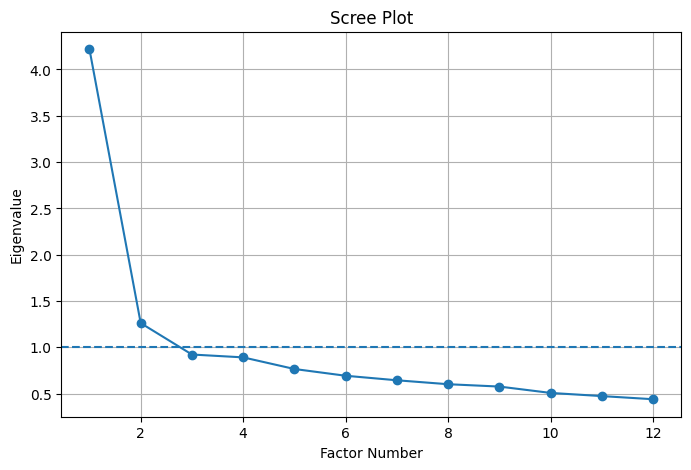


Factor Loadings
                               Factor 1  Factor 2  Factor 3  Factor 4
mindless_use_freq                0.1547    0.2892    0.5107    0.0671
distraction_when_busy_freq       0.0887    0.1924    0.6774    0.1149
restless_without_sm              0.2818    0.2674    0.4044    0.4361
distraction_impact               0.2823    0.6762    0.2330    0.2034
sm_negative_impact_freq          0.3734    0.4686    0.1827    0.1605
concentration_difficulty_freq    0.1713    0.4946    0.3210    0.1526
social_comparison_freq           0.2359    0.2335    0.1892    0.3306
comparison_feelings             -0.1450   -0.0813    0.1438   -0.1701
validation_seeking_freq          0.2128    0.1154    0.1177    0.6832
low_mood_freq                    0.5296    0.1522    0.0938    0.2670
interest_fluctuation_freq        0.6804    0.1982    0.1331    0.1598
sleep_issues_freq                0.4326    0.2731    0.1093    0.1900

Communalities
                             Item  Communality
0          

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
# =========================
# Exploratory Factor Analysis (EFA)
# To validate whether the grouped items form meaningful factors
# =========================

# install once if needed
# !pip install factor_analyzer

import pandas as pd
import numpy as np
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# all questionnaire items used in composite scores
factor_items = [
    'mindless_use_freq', 'distraction_when_busy_freq', 'restless_without_sm', 'distraction_impact',
    'sm_negative_impact_freq', 'concentration_difficulty_freq',
    'social_comparison_freq', 'comparison_feelings', 'validation_seeking_freq',
    'low_mood_freq', 'interest_fluctuation_freq', 'sleep_issues_freq'
]

# keep only numeric complete cases
efa_df = df[factor_items].copy()
efa_df = efa_df.apply(pd.to_numeric, errors='coerce')
efa_df = efa_df.dropna()

# =========================
# 1. Check whether factor analysis is appropriate
# =========================
chi_square_value, bartlett_p = calculate_bartlett_sphericity(efa_df)
kmo_all, kmo_model = calculate_kmo(efa_df)

print("Bartlett's Test of Sphericity")
print(f"Chi-square value: {chi_square_value:.4f}")
print(f"p-value: {bartlett_p:.6f}")

print("\nKMO Test")
print(f"KMO Overall: {kmo_model:.4f}")

# =========================
# 2. Determine number of factors using eigenvalues
# =========================
fa_test = FactorAnalyzer(rotation=None)
fa_test.fit(efa_df)

eigenvalues, vectors = fa_test.get_eigenvalues()

eigen_table = pd.DataFrame({
    "Factor": range(1, len(eigenvalues) + 1),
    "Eigenvalue": eigenvalues
})

print("\nEigenvalues")
print(eigen_table)

# optional scree plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o')
plt.axhline(y=1, linestyle='--')
plt.xlabel("Factor Number")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

# =========================
# 3. Fit factor analysis
# You can change n_factors depending on eigenvalues
# Here using 4 because you defined 4 composite groups
# =========================
fa = FactorAnalyzer(n_factors=4, rotation='varimax')
fa.fit(efa_df)

# factor loadings
loadings = pd.DataFrame(
    fa.loadings_,
    index=factor_items,
    columns=['Factor 1', 'Factor 2', 'Factor 3', 'Factor 4']
)

print("\nFactor Loadings")
print(loadings.round(4))

# =========================
# 4. Communalities and variance explained
# =========================
communalities = pd.DataFrame({
    "Item": factor_items,
    "Communality": fa.get_communalities()
})

variance_df = pd.DataFrame({
    "Factor": ['Factor 1', 'Factor 2', 'Factor 3', 'Factor 4'],
    "SS Loadings": fa.get_factor_variance()[0],
    "Proportion Var": fa.get_factor_variance()[1],
    "Cumulative Var": fa.get_factor_variance()[2]
})

print("\nCommunalities")
print(communalities.round(4))

print("\nVariance Explained")
print(variance_df.round(4))

# optional save
eigen_table.to_csv("efa_eigenvalues.csv", index=False)
loadings.to_csv("efa_factor_loadings.csv")
communalities.to_csv("efa_communalities.csv", index=False)
variance_df.to_csv("efa_variance_explained.csv", index=False)

In [ ]:
df.shape

(1001, 29)

In [ ]:
df['gender'].value_counts()

,count
gender,
Male,589
Female,408
Prefer not to say,4


In [ ]:
df.loc[df['gender'] == 'Male', 'gender'] = 0
df.loc[df['gender'] == 'Female', 'gender'] = 1
df.loc[df['gender'] == 'Prefer not to say', 'gender'] = 2
df['gender'] = df['gender'].astype('int64')

In [ ]:
df

,age,gender,relationship_status,occupation_status,org_affiliation,uses_social_media,platforms_used,daily_time_spent,mindless_use_freq,distraction_when_busy_freq,...,low_mood_freq,interest_fluctuation_freq,sleep_issues_freq,purpose,Anxiety Score,Self Esteem Score,Depression Score,Total Score,Outcome,Outcome Label
0,27,1,Single,Employee,Government / Semi-governmentCorporate / Private,Yes,Facebook;Instagram;YouTube,More than 4 hours,4,2,...,3,4,2.0,10,5,8,9.0,32.0,0,Normal
1,25,0,In a relationship/ Married,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,More than 4 hours,4,5,...,3,4,5.0,18,10,9,12.0,49.0,2,Severe Risk
2,23,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;Linkedin,More than 4 hours,5,5,...,5,3,3.0,20,8,6,11.0,45.0,2,Severe Risk
3,23,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,1-2 hours,3,4,...,1,2,1.0,11,6,6,4.0,27.0,0,Normal
4,20,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;TikTok,More than 4 hours,3,3,...,1,1,3.0,8,4,4,5.0,21.0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,23,0,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;X (Twitter);Linkedin,2-4 hours,5,3,...,3,3,3.0,14,6,4,9.0,33.0,0,Normal
997,21,0,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,1-2 hours,3,3,...,3,3,3.0,12,6,6,9.0,33.0,0,Normal
998,22,1,Single,Student,Academic / Educational,Yes,Facebook,30-60 minutes,1,3,...,2,3,4.0,9,4,5,9.0,27.0,0,Normal
999,25,1,Single,Student,Academic / Educational,Yes,Facebook,30-60 minutes,3,4,...,4,5,5.0,12,5,6,14.0,37.0,1,Moderate Risk


In [ ]:
df['daily_time_spent'].value_counts()

,count
daily_time_spent,
2-4 hours,323
More than 4 hours,260
1-2 hours,225
30-60 minutes,149
Less than 30 minutes,44


In [ ]:
df.loc[df['daily_time_spent'] == 'Less than 30 minutes', 'daily_time_spent'] = 1
df.loc[df['daily_time_spent'] == '30-60 minutes', 'daily_time_spent'] = 2
df.loc[df['daily_time_spent'] == '1-2 hours', 'daily_time_spent'] = 3
df.loc[df['daily_time_spent'] == '2-4 hours', 'daily_time_spent'] = 4
df.loc[df['daily_time_spent'] == 'More than 4 hours', 'daily_time_spent'] = 5

df['daily_time_spent'] = df['daily_time_spent'].astype('int64')

In [ ]:
df

,age,gender,relationship_status,occupation_status,org_affiliation,uses_social_media,platforms_used,daily_time_spent,mindless_use_freq,distraction_when_busy_freq,...,low_mood_freq,interest_fluctuation_freq,sleep_issues_freq,purpose,Anxiety Score,Self Esteem Score,Depression Score,Total Score,Outcome,Outcome Label
0,27,1,Single,Employee,Government / Semi-governmentCorporate / Private,Yes,Facebook;Instagram;YouTube,5,4,2,...,3,4,2.0,10,5,8,9.0,32.0,0,Normal
1,25,0,In a relationship/ Married,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,5,4,5,...,3,4,5.0,18,10,9,12.0,49.0,2,Severe Risk
2,23,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;Linkedin,5,5,5,...,5,3,3.0,20,8,6,11.0,45.0,2,Severe Risk
3,23,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,3,3,4,...,1,2,1.0,11,6,6,4.0,27.0,0,Normal
4,20,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;TikTok,5,3,3,...,1,1,3.0,8,4,4,5.0,21.0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,23,0,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;X (Twitter);Linkedin,4,5,3,...,3,3,3.0,14,6,4,9.0,33.0,0,Normal
997,21,0,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,3,3,3,...,3,3,3.0,12,6,6,9.0,33.0,0,Normal
998,22,1,Single,Student,Academic / Educational,Yes,Facebook,2,1,3,...,2,3,4.0,9,4,5,9.0,27.0,0,Normal
999,25,1,Single,Student,Academic / Educational,Yes,Facebook,2,3,4,...,4,5,5.0,12,5,6,14.0,37.0,1,Moderate Risk


In [ ]:
df.columns

Index(['age', 'gender', 'relationship_status', 'occupation_status',
       'org_affiliation', 'uses_social_media', 'platforms_used',
       'daily_time_spent', 'mindless_use_freq', 'distraction_when_busy_freq',
       'restless_without_sm', 'top_distraction_sources', 'distraction_impact',
       'concentration_difficulty_freq', 'daily_productivity',
       'sm_negative_impact_freq', 'social_comparison_freq',
       'comparison_feelings', 'validation_seeking_freq', 'low_mood_freq',
       'interest_fluctuation_freq', 'sleep_issues_freq', 'purpose',
       'Anxiety Score', 'Self Esteem Score', 'Depression Score', 'Total Score',
       'Outcome', 'Outcome Label'],
      dtype='object')

In [ ]:
df_full = df.copy()

In [ ]:
columns_to_keep = [
    'age', 'gender', 'daily_time_spent',
    'purpose', 'Anxiety Score', 'Self Esteem Score',
    'Depression Score', 'Outcome'
]
df_model = df[columns_to_keep].copy()

In [ ]:
df

,age,gender,relationship_status,occupation_status,org_affiliation,uses_social_media,platforms_used,daily_time_spent,mindless_use_freq,distraction_when_busy_freq,...,low_mood_freq,interest_fluctuation_freq,sleep_issues_freq,purpose,Anxiety Score,Self Esteem Score,Depression Score,Total Score,Outcome,Outcome Label
0,27,1,Single,Employee,Government / Semi-governmentCorporate / Private,Yes,Facebook;Instagram;YouTube,5,4,2,...,3,4,2.0,10,5,8,9.0,32.0,0,Normal
1,25,0,In a relationship/ Married,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,5,4,5,...,3,4,5.0,18,10,9,12.0,49.0,2,Severe Risk
2,23,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;Linkedin,5,5,5,...,5,3,3.0,20,8,6,11.0,45.0,2,Severe Risk
3,23,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,3,3,4,...,1,2,1.0,11,6,6,4.0,27.0,0,Normal
4,20,1,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;Snapchat;TikTok,5,3,3,...,1,1,3.0,8,4,4,5.0,21.0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,23,0,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube;X (Twitter);Linkedin,4,5,3,...,3,3,3.0,14,6,4,9.0,33.0,0,Normal
997,21,0,Single,Student,Academic / Educational,Yes,Facebook;Instagram;YouTube,3,3,3,...,3,3,3.0,12,6,6,9.0,33.0,0,Normal
998,22,1,Single,Student,Academic / Educational,Yes,Facebook,2,1,3,...,2,3,4.0,9,4,5,9.0,27.0,0,Normal
999,25,1,Single,Student,Academic / Educational,Yes,Facebook,2,3,4,...,4,5,5.0,12,5,6,14.0,37.0,1,Moderate Risk


In [ ]:
print(df_model["Outcome"].value_counts())
print(df_model["Outcome"].value_counts(normalize=True) * 100)

Outcome
0    743
1    152
2    106
Name: count, dtype: int64
Outcome
0    74.225774
1    15.184815
2    10.589411
Name: proportion, dtype: float64


In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,743
1,152
2,106


In [ ]:
df_model.corr()

,age,gender,daily_time_spent,purpose,Anxiety Score,Self Esteem Score,Depression Score,Outcome
age,1.000000,0.001381,0.103026,0.077016,0.076470,0.001725,0.112663,0.055316
gender,0.001381,1.000000,0.002007,0.042548,0.097573,0.032641,0.068806,0.053112
daily_time_spent,0.103026,0.002007,1.000000,0.452302,0.320258,0.159549,0.145751,0.345671
purpose,0.077016,0.042548,0.452302,1.000000,0.615288,0.353640,0.495052,0.648995
Anxiety Score,0.076470,0.097573,0.320258,0.615288,1.000000,0.234607,0.489823,0.502650
Self Esteem Score,0.001725,0.032641,0.159549,0.353640,0.234607,1.000000,0.261394,0.521964
Depression Score,0.112663,0.068806,0.145751,0.495052,0.489823,0.261394,1.000000,0.513325
Outcome,0.055316,0.053112,0.345671,0.648995,0.502650,0.521964,0.513325,1.000000


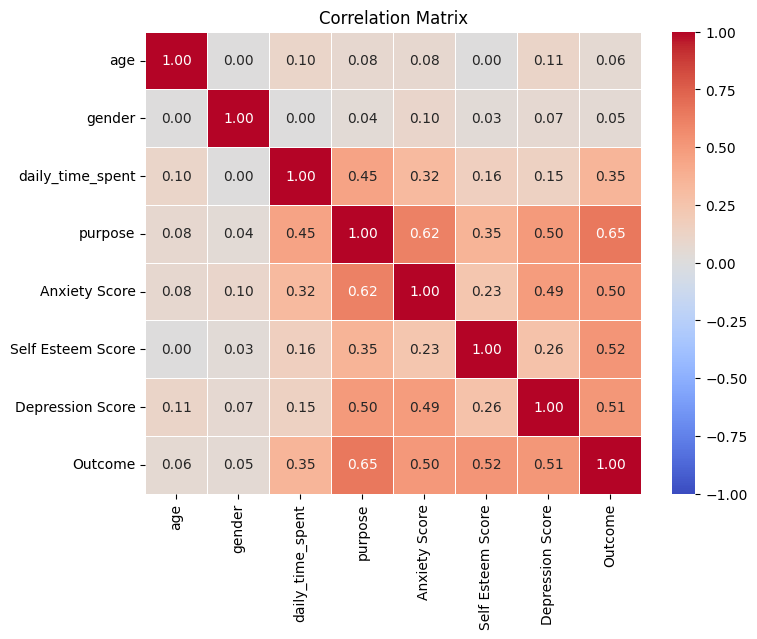

In [ ]:
corr = df_model[['age', 'gender', 'daily_time_spent', 'purpose', 'Anxiety Score', 'Self Esteem Score', 'Depression Score', 'Outcome']].corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)

# Display the heatmap
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df_model

,age,gender,daily_time_spent,purpose,Anxiety Score,Self Esteem Score,Depression Score,Outcome
0,27,1,5,10,5,8,9.0,0
1,25,0,5,18,10,9,12.0,2
2,23,1,5,20,8,6,11.0,2
3,23,1,3,11,6,6,4.0,0
4,20,1,5,8,4,4,5.0,0
...,...,...,...,...,...,...,...,...
996,23,0,4,14,6,4,9.0,0
997,21,0,3,12,6,6,9.0,0
998,22,1,2,9,4,5,9.0,0
999,25,1,2,12,5,6,14.0,1


In [ ]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X = df_model.drop("Outcome", axis=1)
y = df_model["Outcome"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Random seed used: {RANDOM_STATE}")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining set class distribution:")
print(y_train.value_counts())

print("\nTest set class distribution:")
print(y_test.value_counts())

Random seed used: 42
X_train shape: (800, 7)
X_test shape: (201, 7)
y_train shape: (800,)
y_test shape: (201,)

Training set class distribution:
Outcome
0    594
1    121
2     85
Name: count, dtype: int64

Test set class distribution:
Outcome
0    149
1     31
2     21
Name: count, dtype: int64


In [ ]:
# ============================================================
# PROPER CROSS-VALIDATION ON TRAINING SET ONLY
# SMOTE is applied INSIDE each fold
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import numpy as np

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=1)),
    ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro",
        "roc_auc_ovr": "roc_auc_ovr"
    },
    return_train_score=True,
    n_jobs=-1
)

print("CV Accuracy Scores:", cv_results["test_accuracy"])
print(f"CV Mean Accuracy: {np.mean(cv_results['test_accuracy']):.4f}")
print(f"CV Std Dev: {np.std(cv_results['test_accuracy']):.4f}")

# fit final model on full training set
pipeline.fit(X_train, y_train)

# evaluate on untouched test set
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\nTest Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test Precision Macro:", round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4))
print("Test Recall Macro:", round(recall_score(y_test, y_pred, average='macro', zero_division=0), 4))
print("Test F1 Macro:", round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4))

CV Accuracy Scores: [0.98125 0.9875  0.99375 1.      0.975  ]
CV Mean Accuracy: 0.9875
CV Std Dev: 0.0088

Test Accuracy: 0.995
Test Precision Macro: 0.9896
Test Recall Macro: 0.9978
Test F1 Macro: 0.9936


 test accuracy is now only 0.75 percentage points higher than the CV mean:

CV mean: 98.75%
Test: 99.50%

In [ ]:
# ============================================================
# COMPARE ALL MODELS WITH PROPER CV + SMOTE + CLASSIFICATION REPORT
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, label_binarize
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# CLASSIFIERS
# ============================================================
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Support Vector Machine": SVC(probability=True, random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="mlogloss"
    )
}

# ============================================================
# CV SETUP
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

class_labels = {
    0: "Normal",
    1: "Moderate Risk",
    2: "Severe Risk"
}

results = []
all_reports = {}
all_conf_matrices = {}
all_predictions = {}

classes = np.array(sorted(y_train.unique()))

# ============================================================
# LOOP THROUGH ALL MODELS
# ============================================================
for model_name, model in classifiers.items():
    print("\n" + "=" * 80)
    print(f"MODEL: {model_name}")
    print("=" * 80)

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=1)),
        ("clf", model)
    ])

    # cross-validation on TRAINING SET ONLY
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision_macro": "precision_macro",
            "recall_macro": "recall_macro",
            "f1_macro": "f1_macro",
            "roc_auc_ovr": "roc_auc_ovr"
        },
        return_train_score=True,
        n_jobs=-1
    )

    # fit final model on full training set
    pipeline.fit(X_train, y_train)

    # predict on untouched test set
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)

    # test metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    test_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    test_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    y_test_bin = label_binarize(y_test, classes=classes)
    test_auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="macro")

    # classification report
    report = classification_report(
        y_test,
        y_pred,
        target_names=[class_labels[c] for c in sorted(class_labels.keys())],
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).transpose()
    all_reports[model_name] = report_df
    all_conf_matrices[model_name] = confusion_matrix(y_test, y_pred)
    all_predictions[model_name] = {"y_pred": y_pred, "y_prob": y_prob, "pipeline": pipeline}

    # print summary
    print("CV Accuracy Scores:", cv_results["test_accuracy"])
    print(f"CV Mean Accuracy: {np.mean(cv_results['test_accuracy']):.4f}")
    print(f"CV Std Dev: {np.std(cv_results['test_accuracy']):.4f}")

    print("\nTest Accuracy:", round(test_accuracy, 4))
    print("Test Precision Macro:", round(test_precision, 4))
    print("Test Recall Macro:", round(test_recall, 4))
    print("Test F1 Macro:", round(test_f1, 4))
    print("Test AUC OVR Macro:", round(test_auc, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=[class_labels[c] for c in sorted(class_labels.keys())],
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # store overall results
    results.append({
        "Model": model_name,
        "CV_Train_Accuracy_Mean": round(np.mean(cv_results["train_accuracy"]), 4),
        "CV_Test_Accuracy_Mean": round(np.mean(cv_results["test_accuracy"]), 4),
        "CV_Test_Accuracy_SD": round(np.std(cv_results["test_accuracy"]), 4),
        "CV_Test_Precision_Macro_Mean": round(np.mean(cv_results["test_precision_macro"]), 4),
        "CV_Test_Recall_Macro_Mean": round(np.mean(cv_results["test_recall_macro"]), 4),
        "CV_Test_F1_Macro_Mean": round(np.mean(cv_results["test_f1_macro"]), 4),
        "CV_Test_AUC_OVR_Mean": round(np.mean(cv_results["test_roc_auc_ovr"]), 4),
        "Test_Accuracy": round(test_accuracy, 4),
        "Test_Precision_Macro": round(test_precision, 4),
        "Test_Recall_Macro": round(test_recall, 4),
        "Test_F1_Macro": round(test_f1, 4),
        "Test_AUC_OVR_Macro": round(test_auc, 4)
    })

# ============================================================
# FINAL COMPARISON TABLE
# ============================================================
results_df = pd.DataFrame(results)

# sort by overall performance
results_df = results_df.sort_values(
    by=["Test_F1_Macro", "Test_AUC_OVR_Macro", "Test_Accuracy", "CV_Test_Accuracy_Mean"],
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 80)
print(results_df)

# save results
results_df.to_csv("model_comparison_results.csv", index=False)

# ============================================================
# BEST MODEL
# ============================================================
best_model_name = results_df.loc[0, "Model"]
best_model_info = all_predictions[best_model_name]
best_pipeline = best_model_info["pipeline"]
best_y_pred = best_model_info["y_pred"]
best_y_prob = best_model_info["y_prob"]

print("\n" + "=" * 80)
print(f"BEST MODEL BASED ON OVERALL PERFORMANCE: {best_model_name}")
print("=" * 80)
print(results_df.loc[0])

print("\nBest Model Classification Report:")
print(classification_report(
    y_test,
    best_y_pred,
    target_names=[class_labels[c] for c in sorted(class_labels.keys())],
    zero_division=0
))

print("Best Model Confusion Matrix:")
print(confusion_matrix(y_test, best_y_pred))

# ============================================================
# CLASS-WISE AUC FOR BEST MODEL
# ============================================================
auc_rows = []
for i, c in enumerate(classes):
    auc_value = roc_auc_score(y_test_bin[:, i], best_y_prob[:, i])
    auc_rows.append({
        "Class_Code": int(c),
        "Class_Label": class_labels[int(c)],
        "AUC_OVR": round(auc_value, 4)
    })

best_auc_table = pd.DataFrame(auc_rows)

print("\nClass-wise AUC for Best Model:")
print(best_auc_table)

best_auc_table.to_csv("best_model_classwise_auc.csv", index=False)


MODEL: Logistic Regression
CV Accuracy Scores: [0.98125 0.9875  0.99375 1.      0.975  ]
CV Mean Accuracy: 0.9875
CV Std Dev: 0.0088

Test Accuracy: 0.995
Test Precision Macro: 0.9896
Test Recall Macro: 0.9978
Test F1 Macro: 0.9936
Test AUC OVR Macro: 1.0

Classification Report:
               precision    recall  f1-score   support

       Normal       1.00      0.99      1.00       149
Moderate Risk       0.97      1.00      0.98        31
  Severe Risk       1.00      1.00      1.00        21

     accuracy                           1.00       201
    macro avg       0.99      1.00      0.99       201
 weighted avg       1.00      1.00      1.00       201

Confusion Matrix:
[[148   1   0]
 [  0  31   0]
 [  0   0  21]]

MODEL: Decision Tree
CV Accuracy Scores: [0.9125  0.94375 0.86875 0.91875 0.90625]
CV Mean Accuracy: 0.9100
CV Std Dev: 0.0242

Test Accuracy: 0.8756
Test Precision Macro: 0.7675
Test Recall Macro: 0.7055
Test F1 Macro: 0.7305
Test AUC OVR Macro: 0.8062

Classificat

In [ ]:
# ============================================================
# 95% CONFIDENCE INTERVALS FOR PERFORMANCE METRICS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

def bootstrap_metric_ci(y_true, y_pred, metric_func, n_bootstrap=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    n = len(y_true)
    scores = []

    for _ in range(n_bootstrap):
        indices = rng.choice(np.arange(n), size=n, replace=True)
        y_true_sample = y_true[indices]
        y_pred_sample = y_pred[indices]

        try:
            score = metric_func(y_true_sample, y_pred_sample)
            scores.append(score)
        except:
            continue

    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)
    return lower, upper


def bootstrap_auc_ci(y_true, y_prob, classes, n_bootstrap=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    n = len(y_true)
    auc_scores = []

    for _ in range(n_bootstrap):
        indices = rng.choice(np.arange(n), size=n, replace=True)
        y_true_sample = y_true[indices]
        y_prob_sample = y_prob[indices]

        # skip bootstrap samples that do not contain all classes
        if len(np.unique(y_true_sample)) < len(classes):
            continue

        y_true_bin = label_binarize(y_true_sample, classes=classes)

        try:
            auc_score = roc_auc_score(
                y_true_bin,
                y_prob_sample,
                multi_class="ovr",
                average="macro"
            )
            auc_scores.append(auc_score)
        except:
            continue

    lower = np.percentile(auc_scores, 2.5)
    upper = np.percentile(auc_scores, 97.5)
    return lower, upper


# ============================================================
# CURRENT METRICS
# ============================================================
classes = np.array(sorted(np.unique(y_test)))

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

y_test_bin = label_binarize(y_test, classes=classes)
auc_macro = roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="macro")

# ============================================================
# BOOTSTRAP CIs
# ============================================================
acc_ci = bootstrap_metric_ci(y_test, y_pred, accuracy_score)
prec_ci = bootstrap_metric_ci(
    y_test, y_pred,
    lambda yt, yp: precision_score(yt, yp, average="macro", zero_division=0)
)
rec_ci = bootstrap_metric_ci(
    y_test, y_pred,
    lambda yt, yp: recall_score(yt, yp, average="macro", zero_division=0)
)
f1_ci = bootstrap_metric_ci(
    y_test, y_pred,
    lambda yt, yp: f1_score(yt, yp, average="macro", zero_division=0)
)
auc_ci = bootstrap_auc_ci(y_test, y_prob, classes=classes)

# ============================================================
# FINAL TABLE
# ============================================================
ci_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision Macro", "Recall Macro", "F1 Macro", "AUC OVR Macro"],
    "Estimate": [acc, prec, rec, f1, auc_macro],
    "CI Lower (95%)": [acc_ci[0], prec_ci[0], rec_ci[0], f1_ci[0], auc_ci[0]],
    "CI Upper (95%)": [acc_ci[1], prec_ci[1], rec_ci[1], f1_ci[1], auc_ci[1]]
})

ci_table = ci_table.round(4)

print("Performance Metrics with 95% Confidence Intervals")
print(ci_table)

# optional save
ci_table.to_csv("performance_metrics_with_95CI.csv", index=False)

Performance Metrics with 95% Confidence Intervals
            Metric  Estimate  CI Lower (95%)  CI Upper (95%)
0         Accuracy    0.9055          0.8657          0.9453
1  Precision Macro    0.8107          0.7172          0.8948
2     Recall Macro    0.7854          0.6924          0.8698
3         F1 Macro    0.7966          0.7038          0.8751
4    AUC OVR Macro    0.9836          0.9722          0.9931


In [ ]:
# ============================================================
# SENSITIVITY ANALYSIS:
# WITH AND WITHOUT SYMPTOM-RELATED ITEMS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# ============================================================
# 1. CHOOSE THE BEST MODEL PROPERLY
# ============================================================

best_model_name = "Logistic Regression"

model_lookup = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Support Vector Machine": SVC(probability=True, random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss")
}

best_model = model_lookup[best_model_name]

print("Best model selected:", best_model_name)
print("Estimator object:", best_model)

# ============================================================
# 2. DEFINE FEATURE SETS
# ============================================================

behavior_features = [
    "age",
    "gender",
    "daily_time_spent",
    "purpose"
]

symptom_features = [
    "Anxiety Score",
    "Self Esteem Score",
    "Depression Score"
]

feature_sets = {
    "Behavior_Only": behavior_features,
    "Behavior_Plus_Symptoms": behavior_features + symptom_features
}

class_labels = {
    0: "Normal",
    1: "Moderate Risk",
    2: "Severe Risk"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

sensitivity_results = []
sensitivity_details = {}

# ============================================================
# 3. RUN SAME MODEL ON BOTH FEATURE SETS
# ============================================================

for set_name, features in feature_sets.items():
    print("\n" + "=" * 80)
    print(f"SENSITIVITY ANALYSIS: {set_name}")
    print("=" * 80)
    print("Features used:", features)

    model_df_temp = df_model[features + ["Outcome"]].copy()
    model_df_temp = model_df_temp.apply(pd.to_numeric, errors="coerce").dropna()

    X = model_df_temp[features]
    y = model_df_temp["Outcome"].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE
    )

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=1)),
        ("clf", model_lookup[best_model_name])
    ])

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision_macro": "precision_macro",
            "recall_macro": "recall_macro",
            "f1_macro": "f1_macro",
            "roc_auc_ovr": "roc_auc_ovr"
        },
        return_train_score=True,
        n_jobs=-1
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)

    classes = np.array(sorted(y.unique()))
    y_test_bin = label_binarize(y_test, classes=classes)

    result = {
        "Best_Model": best_model_name,
        "Feature_Set": set_name,
        "Features_Used": ", ".join(features),

        "CV_Train_Accuracy_Mean": round(np.mean(cv_results["train_accuracy"]), 4),
        "CV_Test_Accuracy_Mean": round(np.mean(cv_results["test_accuracy"]), 4),
        "CV_Test_Accuracy_SD": round(np.std(cv_results["test_accuracy"]), 4),

        "CV_Test_Precision_Macro_Mean": round(np.mean(cv_results["test_precision_macro"]), 4),
        "CV_Test_Recall_Macro_Mean": round(np.mean(cv_results["test_recall_macro"]), 4),
        "CV_Test_F1_Macro_Mean": round(np.mean(cv_results["test_f1_macro"]), 4),
        "CV_Test_AUC_OVR_Mean": round(np.mean(cv_results["test_roc_auc_ovr"]), 4),

        "Test_Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Test_Precision_Macro": round(precision_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Test_Recall_Macro": round(recall_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Test_F1_Macro": round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Test_AUC_OVR_Macro": round(
            roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="macro"), 4
        )
    }

    sensitivity_results.append(result)

    sensitivity_details[set_name] = {
        "y_test": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "pipeline": pipeline
    }

    print(f"CV Mean Accuracy: {result['CV_Test_Accuracy_Mean']:.4f}")
    print(f"CV Std Dev: {result['CV_Test_Accuracy_SD']:.4f}")
    print(f"Test Accuracy: {result['Test_Accuracy']:.4f}")
    print(f"Test Precision Macro: {result['Test_Precision_Macro']:.4f}")
    print(f"Test Recall Macro: {result['Test_Recall_Macro']:.4f}")
    print(f"Test F1 Macro: {result['Test_F1_Macro']:.4f}")
    print(f"Test AUC OVR Macro: {result['Test_AUC_OVR_Macro']:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=[class_labels[c] for c in sorted(class_labels.keys())],
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# ============================================================
# 4. FINAL SENSITIVITY TABLE
# ============================================================

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df = sensitivity_df.sort_values(by="Feature_Set").reset_index(drop=True)

print("\n" + "=" * 80)
print("SENSITIVITY ANALYSIS RESULTS")
print("=" * 80)
print(sensitivity_df)

sensitivity_df.to_csv("sensitivity_analysis_best_model.csv", index=False)

Best model selected: Logistic Regression
Estimator object: LogisticRegression(max_iter=3000, random_state=42)

SENSITIVITY ANALYSIS: Behavior_Only
Features used: ['age', 'gender', 'daily_time_spent', 'purpose']
CV Mean Accuracy: 0.7075
CV Std Dev: 0.0573
Test Accuracy: 0.7015
Test Precision Macro: 0.5951
Test Recall Macro: 0.6238
Test F1 Macro: 0.5929
Test AUC OVR Macro: 0.8569

Classification Report:
               precision    recall  f1-score   support

       Normal       0.93      0.75      0.83       149
Moderate Risk       0.29      0.55      0.38        31
  Severe Risk       0.57      0.57      0.57        21

     accuracy                           0.70       201
    macro avg       0.60      0.62      0.59       201
 weighted avg       0.79      0.70      0.73       201

Confusion Matrix:
[[112  35   2]
 [  7  17   7]
 [  2   7  12]]

SENSITIVITY ANALYSIS: Behavior_Plus_Symptoms
Features used: ['age', 'gender', 'daily_time_spent', 'purpose', 'Anxiety Score', 'Self Esteem Sco

Type of shap_values: <class 'numpy.ndarray'>
Shape info: (201, 7, 3)

SHAP Summary Plot for class 0: Normal


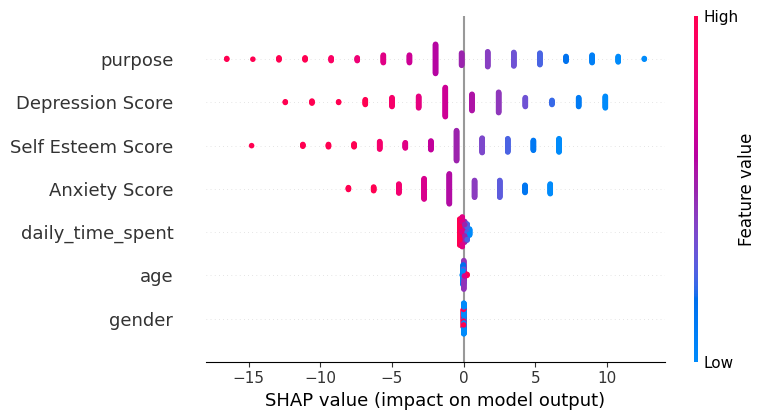


SHAP Summary Plot for class 1: Moderate Risk


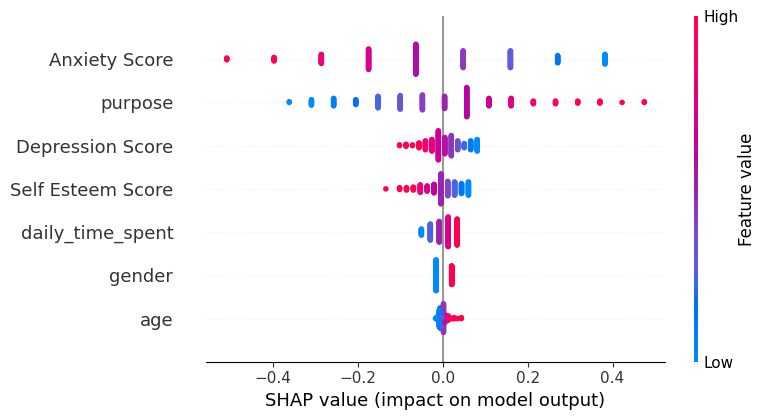


SHAP Summary Plot for class 2: Severe Risk


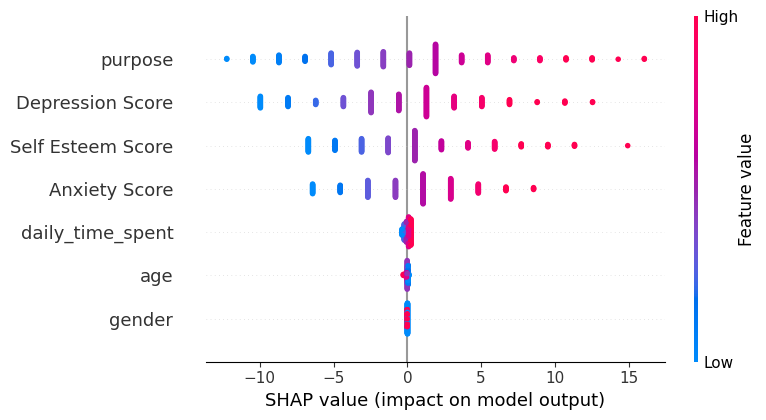

In [ ]:
# ============================================================
# SHAP SUMMARY / BEESWARM PLOTS FOR LOGISTIC REGRESSION
# ============================================================

import shap
import pandas as pd
import numpy as np

# get fitted scaler and classifier from pipeline
scaler = pipeline.named_steps["scaler"]
clf = pipeline.named_steps["clf"]

# transform using scaler learned from training data only
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convert to DataFrame so feature names appear properly
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# SHAP explainer for logistic regression
explainer = shap.LinearExplainer(clf, X_train_scaled_df)
shap_values = explainer.shap_values(X_test_scaled_df)

print("Type of shap_values:", type(shap_values))
print("Shape info:", np.array(shap_values).shape if not isinstance(shap_values, list) else [np.array(sv).shape for sv in shap_values])

# ============================================================
# SUMMARY / BEESWARM PLOTS
# ============================================================

class_labels = {
    0: "Normal",
    1: "Moderate Risk",
    2: "Severe Risk"
}

# multiclass case
if isinstance(shap_values, list):
    for class_idx, sv in enumerate(shap_values):
        print(f"\nSHAP Summary Plot for class {class_idx}: {class_labels.get(class_idx, class_idx)}")
        shap.summary_plot(
            sv,
            X_test_scaled_df,
            feature_names=X_test_scaled_df.columns.tolist(),
            show=True
        )

else:
    # some SHAP versions return a 3D array for multiclass
    shap_array = np.array(shap_values)

    if shap_array.ndim == 3:
        # shape may be (n_samples, n_features, n_classes)
        if shap_array.shape[0] == X_test_scaled_df.shape[0]:
            for class_idx in range(shap_array.shape[2]):
                print(f"\nSHAP Summary Plot for class {class_idx}: {class_labels.get(class_idx, class_idx)}")
                shap.summary_plot(
                    shap_array[:, :, class_idx],
                    X_test_scaled_df,
                    feature_names=X_test_scaled_df.columns.tolist(),
                    show=True
                )

        # shape may be (n_classes, n_samples, n_features)
        elif shap_array.shape[1] == X_test_scaled_df.shape[0]:
            for class_idx in range(shap_array.shape[0]):
                print(f"\nSHAP Summary Plot for class {class_idx}: {class_labels.get(class_idx, class_idx)}")
                shap.summary_plot(
                    shap_array[class_idx, :, :],
                    X_test_scaled_df,
                    feature_names=X_test_scaled_df.columns.tolist(),
                    show=True
                )

    else:
        shap.summary_plot(
            shap_values,
            X_test_scaled_df,
            feature_names=X_test_scaled_df.columns.tolist(),
            show=True
        )


SHAP Bar Plot for class 0: Normal


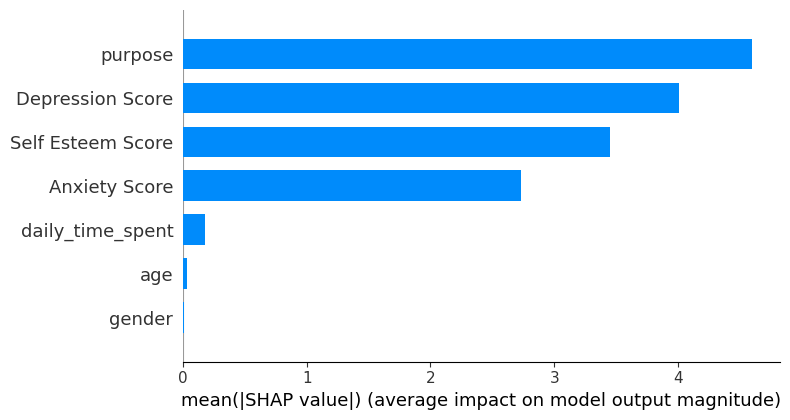


SHAP Bar Plot for class 1: Moderate Risk


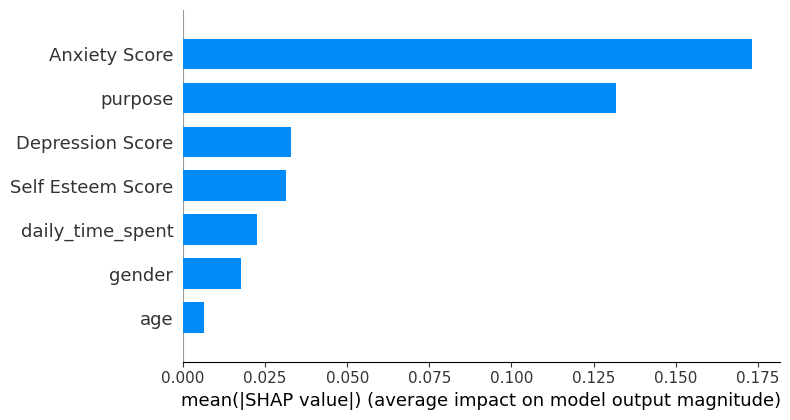


SHAP Bar Plot for class 2: Severe Risk


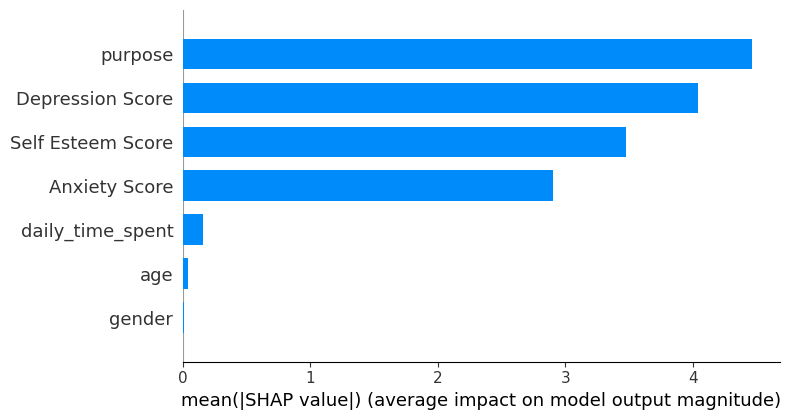

In [ ]:
# ============================================================
# SHAP BAR PLOTS (GLOBAL FEATURE IMPORTANCE)
# ============================================================

if isinstance(shap_values, list):
    for class_idx, sv in enumerate(shap_values):
        print(f"\nSHAP Bar Plot for class {class_idx}: {class_labels.get(class_idx, class_idx)}")
        shap.summary_plot(
            sv,
            X_test_scaled_df,
            feature_names=X_test_scaled_df.columns.tolist(),
            plot_type="bar",
            show=True
        )
else:
    shap_array = np.array(shap_values)

    if shap_array.ndim == 3:
        if shap_array.shape[0] == X_test_scaled_df.shape[0]:
            for class_idx in range(shap_array.shape[2]):
                print(f"\nSHAP Bar Plot for class {class_idx}: {class_labels.get(class_idx, class_idx)}")
                shap.summary_plot(
                    shap_array[:, :, class_idx],
                    X_test_scaled_df,
                    feature_names=X_test_scaled_df.columns.tolist(),
                    plot_type="bar",
                    show=True
                )
        elif shap_array.shape[1] == X_test_scaled_df.shape[0]:
            for class_idx in range(shap_array.shape[0]):
                print(f"\nSHAP Bar Plot for class {class_idx}: {class_labels.get(class_idx, class_idx)}")
                shap.summary_plot(
                    shap_array[class_idx, :, :],
                    X_test_scaled_df,
                    feature_names=X_test_scaled_df.columns.tolist(),
                    plot_type="bar",
                    show=True
                )

CV Accuracy Scores: [0.98125 0.9875  0.99375 1.      0.975  ]
CV Mean Accuracy: 0.9875
CV Std Dev: 0.0088

Classification Report:
               precision    recall  f1-score   support

       Normal       1.00      0.99      1.00       149
Moderate Risk       0.97      1.00      0.98        31
  Severe Risk       1.00      1.00      1.00        21

     accuracy                           1.00       201
    macro avg       0.99      1.00      0.99       201
 weighted avg       1.00      1.00      1.00       201

Confusion Matrix:
[[148   1   0]
 [  0  31   0]
 [  0   0  21]]


<Figure size 600x500 with 0 Axes>

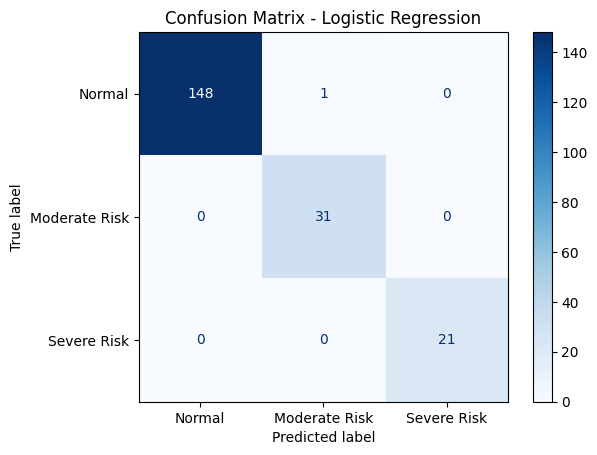

Test Accuracy: 0.9950
Test Precision Macro: 0.9896
Test Recall Macro: 0.9978
Test F1 Macro: 0.9936


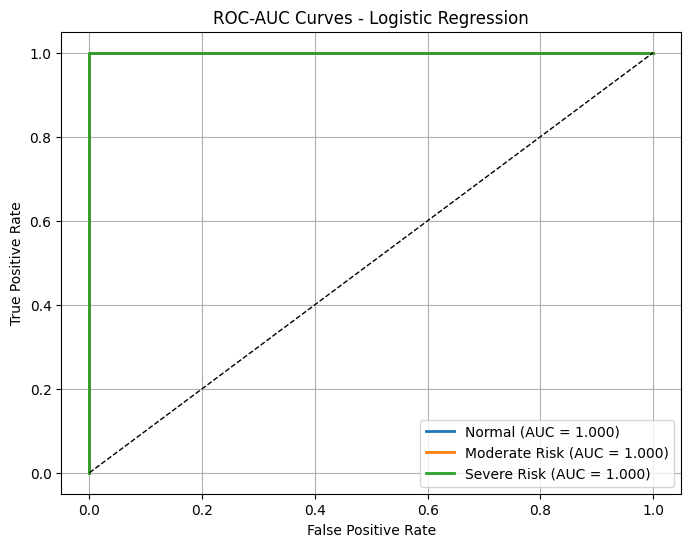


Class-wise ROC-AUC:
   Class_Code    Class_Label  AUC
0           0         Normal  1.0
1           1  Moderate Risk  1.0
2           2    Severe Risk  1.0

Macro AUC OVR: 1.0000


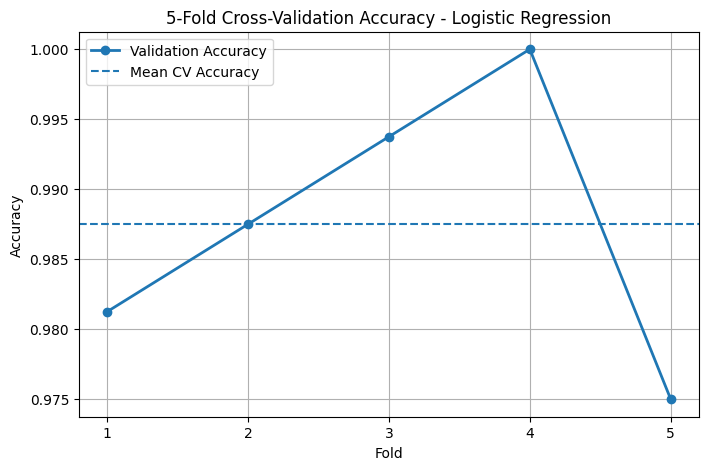

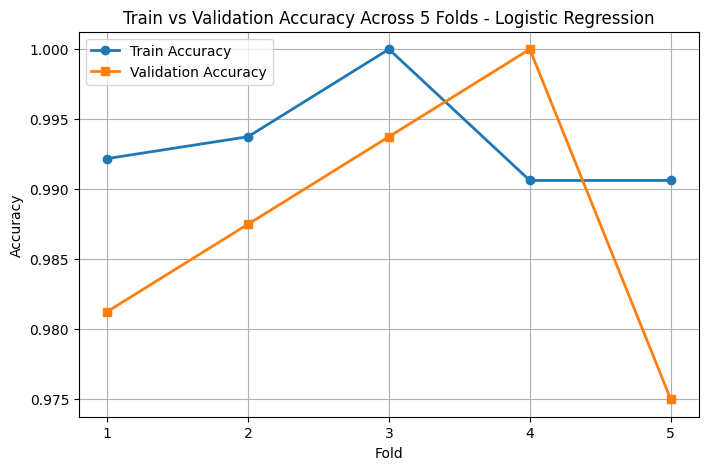

In [ ]:
# ============================================================
# LOGISTIC REGRESSION:
# Classification Report + Confusion Matrix + ROC-AUC Curve
# + 5-Fold Cross-Validation Wave Plot
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# ============================================================
# 1. PIPELINE
# ============================================================
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=1)),
    ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
])

# ============================================================
# 2. 5-FOLD CROSS-VALIDATION ON TRAINING SET ONLY
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro",
        "roc_auc_ovr": "roc_auc_ovr"
    },
    return_train_score=True,
    n_jobs=-1
)

print("CV Accuracy Scores:", cv_results["test_accuracy"])
print(f"CV Mean Accuracy: {np.mean(cv_results['test_accuracy']):.4f}")
print(f"CV Std Dev: {np.std(cv_results['test_accuracy']):.4f}")

# ============================================================
# 3. FIT FINAL MODEL ON FULL TRAINING SET
# ============================================================
pipeline.fit(X_train, y_train)

# ============================================================
# 4. PREDICT ON TEST SET
# ============================================================
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)

class_labels = {
    0: "Normal",
    1: "Moderate Risk",
    2: "Severe Risk"
}

# ============================================================
# 5. CLASSIFICATION REPORT
# ============================================================
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=[class_labels[c] for c in sorted(class_labels.keys())],
    zero_division=0
))

# ============================================================
# 6. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[class_labels[c] for c in sorted(class_labels.keys())]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# ============================================================
# 7. TEST METRICS
# ============================================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Precision Macro: {prec:.4f}")
print(f"Test Recall Macro: {rec:.4f}")
print(f"Test F1 Macro: {f1:.4f}")

# ============================================================
# 8. ROC-AUC CURVES (ONE-VS-REST, MULTICLASS)
# ============================================================
classes = np.array(sorted(y_test.unique()))
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

auc_rows = []

for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    auc_rows.append({
        "Class_Code": int(c),
        "Class_Label": class_labels[int(c)],
        "AUC": round(roc_auc, 4)
    })

    plt.plot(fpr, tpr, linewidth=2, label=f"{class_labels[int(c)]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

auc_table = pd.DataFrame(auc_rows)
print("\nClass-wise ROC-AUC:")
print(auc_table)

macro_auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="macro")
print(f"\nMacro AUC OVR: {macro_auc:.4f}")

# ============================================================
# 9. 5-FOLD VALIDATION WAVE-LIKE DIAGRAM
# ============================================================
folds = np.arange(1, 6)

plt.figure(figsize=(8, 5))
plt.plot(folds, cv_results["test_accuracy"], marker="o", linewidth=2, label="Validation Accuracy")
plt.axhline(np.mean(cv_results["test_accuracy"]), linestyle="--", linewidth=1.5, label="Mean CV Accuracy")

plt.xticks(folds)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 10. OPTIONAL: WAVE PLOT WITH TRAIN VS VALIDATION
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(folds, cv_results["train_accuracy"], marker="o", linewidth=2, label="Train Accuracy")
plt.plot(folds, cv_results["test_accuracy"], marker="s", linewidth=2, label="Validation Accuracy")

plt.xticks(folds)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy Across 5 Folds - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

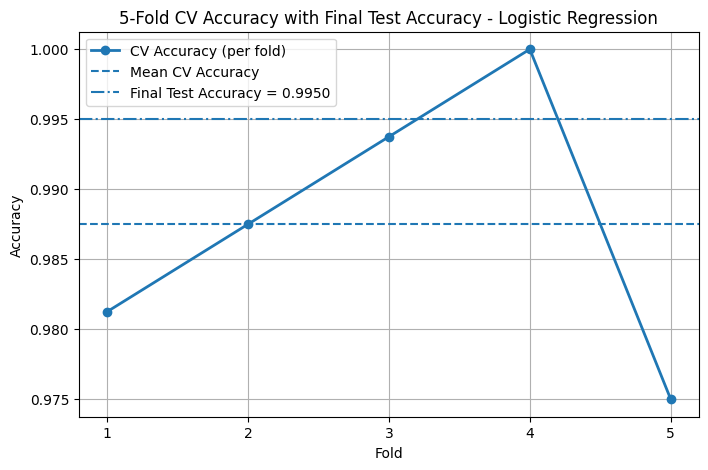

In [ ]:
# ============================================================
# 5-FOLD CV ACCURACY PLOT + FINAL TEST ACCURACY LINE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# final test accuracy
test_acc = accuracy_score(y_test, y_pred)

folds = np.arange(1, 6)

plt.figure(figsize=(8, 5))
plt.plot(folds, cv_results["test_accuracy"], marker="o", linewidth=2, label="CV Accuracy (per fold)")
plt.axhline(np.mean(cv_results["test_accuracy"]), linestyle="--", linewidth=1.5, label="Mean CV Accuracy")
plt.axhline(test_acc, linestyle="-.", linewidth=1.5, label=f"Final Test Accuracy = {test_acc:.4f}")

plt.xticks(folds)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold CV Accuracy with Final Test Accuracy - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

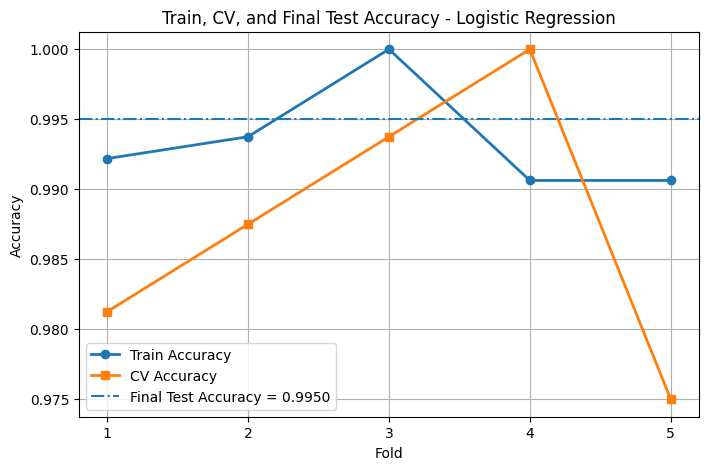

In [ ]:
folds = np.arange(1, 6)
test_acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(8, 5))
plt.plot(folds, cv_results["train_accuracy"], marker="o", linewidth=2, label="Train Accuracy")
plt.plot(folds, cv_results["test_accuracy"], marker="s", linewidth=2, label="CV Accuracy")
plt.axhline(test_acc, linestyle="-.", linewidth=1.5, label=f"Final Test Accuracy = {test_acc:.4f}")

plt.xticks(folds)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Train, CV, and Final Test Accuracy - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# REPORT AUC VALUES FOR EACH CLASS
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

class_labels = {
    0: "Normal",
    1: "Moderate Risk",
    2: "Severe Risk"
}

classes = np.array(sorted(y_test.unique()))
y_test_bin = label_binarize(y_test, classes=classes)

auc_rows = []

for i, c in enumerate(classes):
    auc_value = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    auc_rows.append({
        "Class_Code": int(c),
        "Class_Label": class_labels[int(c)],
        "AUC": round(auc_value, 4)
    })

auc_table = pd.DataFrame(auc_rows)

print("AUC Values for Each Class")
print(auc_table)

# optional save
auc_table.to_csv("auc_values_each_class.csv", index=False)

AUC Values for Each Class
   Class_Code    Class_Label  AUC
0           0         Normal  1.0
1           1  Moderate Risk  1.0
2           2    Severe Risk  1.0


In [ ]:
# ============================================================
# REPORT HYPERPARAMETERS FOR ALL MODELS
# ============================================================

import pandas as pd

hyperparameter_rows = []

for model_name, model in classifiers.items():
    params = model.get_params()

    for param_name, param_value in params.items():
        hyperparameter_rows.append({
            "Model": model_name,
            "Hyperparameter": param_name,
            "Value": param_value
        })

hyperparameter_table = pd.DataFrame(hyperparameter_rows)

print("Hyperparameter Table for All Models")
print(hyperparameter_table)

# optional save
hyperparameter_table.to_csv("all_model_hyperparameters.csv", index=False)

Hyperparameter Table for All Models
                   Model       Hyperparameter  Value
0    Logistic Regression                    C    1.0
1    Logistic Regression         class_weight   None
2    Logistic Regression                 dual  False
3    Logistic Regression        fit_intercept   True
4    Logistic Regression    intercept_scaling      1
..                   ...                  ...    ...
127              XGBoost     scale_pos_weight   None
128              XGBoost            subsample   None
129              XGBoost          tree_method   None
130              XGBoost  validate_parameters   None
131              XGBoost            verbosity   None

[132 rows x 3 columns]


In [ ]:
# ============================================================
# REPORT HYPERPARAMETERS FOR BEST MODEL ONLY
# ============================================================

best_model = classifiers[best_model_name]
best_params = best_model.get_params()

best_hyperparameter_table = pd.DataFrame({
    "Hyperparameter": list(best_params.keys()),
    "Value": list(best_params.values())
})

print(f"Hyperparameters for Best Model: {best_model_name}")
print(best_hyperparameter_table)

# optional save
best_hyperparameter_table.to_csv("best_model_hyperparameters.csv", index=False)

Hyperparameters for Best Model: Logistic Regression
       Hyperparameter       Value
0                   C         1.0
1        class_weight        None
2                dual       False
3       fit_intercept        True
4   intercept_scaling           1
5            l1_ratio        None
6            max_iter        3000
7         multi_class  deprecated
8              n_jobs        None
9             penalty          l2
10       random_state          42
11             solver       lbfgs
12                tol      0.0001
13            verbose           0
14         warm_start       False


In [ ]:
# ============================================================
# REPORT PIPELINE + CLASSIFIER HYPERPARAMETERS
# ============================================================

pipeline_params = pipeline.get_params()

pipeline_hyperparameter_table = pd.DataFrame({
    "Parameter": list(pipeline_params.keys()),
    "Value": list(pipeline_params.values())
})

print("Pipeline Hyperparameters")
print(pipeline_hyperparameter_table)

# optional save
pipeline_hyperparameter_table.to_csv("pipeline_hyperparameters.csv", index=False)

Pipeline Hyperparameters
                   Parameter  \
0                     memory   
1                      steps   
2            transform_input   
3                    verbose   
4                     scaler   
5                      smote   
6                        clf   
7               scaler__copy   
8          scaler__with_mean   
9           scaler__with_std   
10        smote__k_neighbors   
11       smote__random_state   
12  smote__sampling_strategy   
13                    clf__C   
14         clf__class_weight   
15                 clf__dual   
16        clf__fit_intercept   
17    clf__intercept_scaling   
18             clf__l1_ratio   
19             clf__max_iter   
20          clf__multi_class   
21               clf__n_jobs   
22              clf__penalty   
23         clf__random_state   
24               clf__solver   
25                  clf__tol   
26              clf__verbose   
27           clf__warm_start   

                                              

In [ ]:
# ============================================================
# SOFTWARE AND LIBRARY VERSIONS
# ============================================================

import sys
import platform
import pandas as pd
import numpy as np
import sklearn
import imblearn
import matplotlib
import seaborn as sns
import scipy
import shap
import xgboost

software_versions = pd.DataFrame({
    "Software / Library": [
        "Python",
        "Platform",
        "pandas",
        "numpy",
        "scikit-learn",
        "imbalanced-learn",
        "matplotlib",
        "seaborn",
        "scipy",
        "shap",
        "xgboost"
    ],
    "Version": [
        sys.version.split()[0],
        platform.platform(),
        pd.__version__,
        np.__version__,
        sklearn.__version__,
        imblearn.__version__,
        matplotlib.__version__,
        sns.__version__,
        scipy.__version__,
        shap.__version__,
        xgboost.__version__
    ]
})

print("Software and Library Versions")
print(software_versions)

# optional save
software_versions.to_csv("software_library_versions.csv", index=False)

Software and Library Versions
   Software / Library                               Version
0              Python                               3.12.13
1            Platform  Linux-6.6.113+-x86_64-with-glibc2.35
2              pandas                                 2.2.2
3               numpy                                 2.0.2
4        scikit-learn                                 1.6.1
5    imbalanced-learn                                0.14.1
6          matplotlib                                3.10.0
7             seaborn                                0.13.2
8               scipy                                1.16.3
9                shap                                0.51.0
10            xgboost                                 3.2.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

type: <class 'numpy.ndarray'>
shape: (201, 7, 7, 3)

Interaction summary for class 0: Normal
class slice shape: (201, 7, 7)


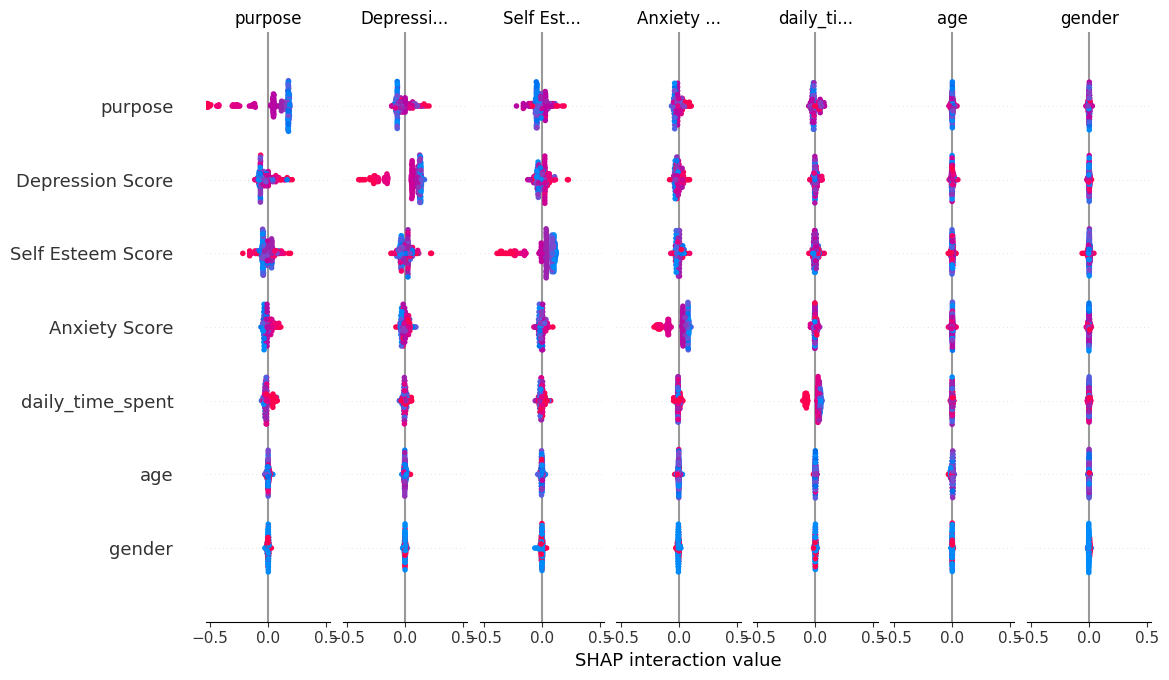

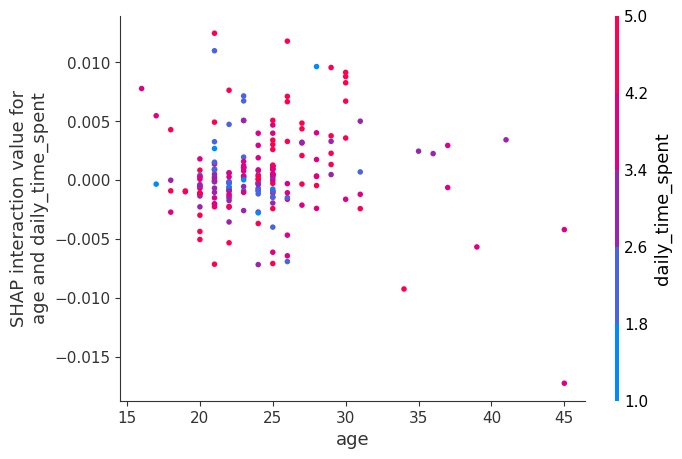


Interaction summary for class 1: Moderate Risk
class slice shape: (201, 7, 7)


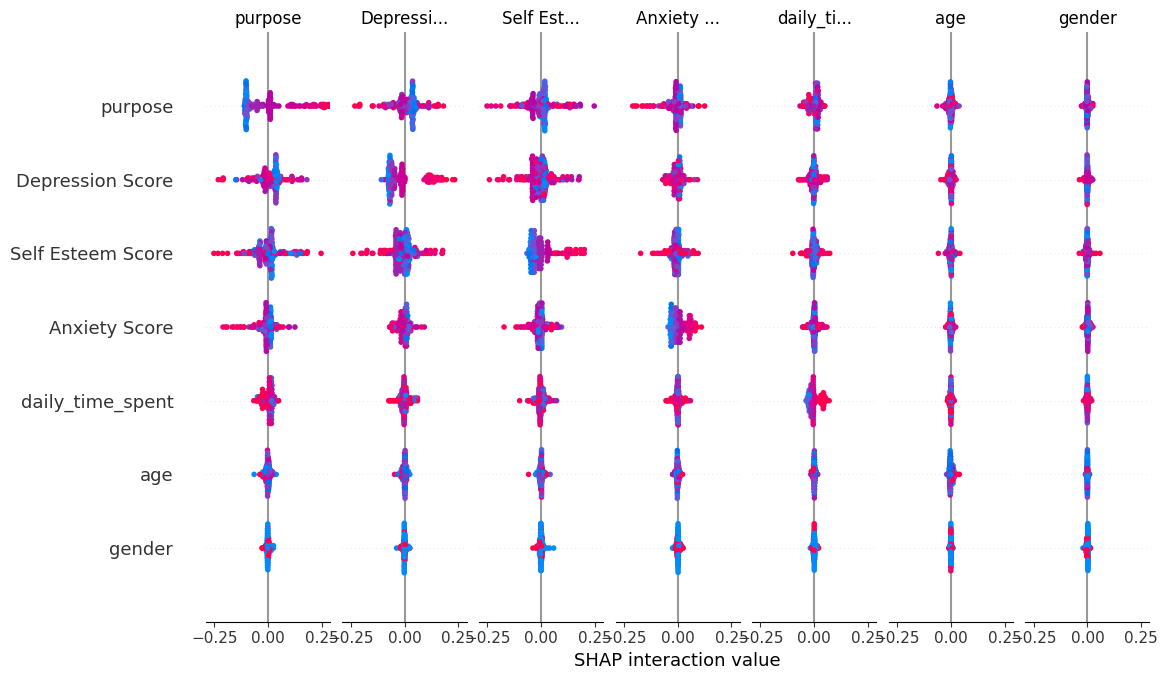

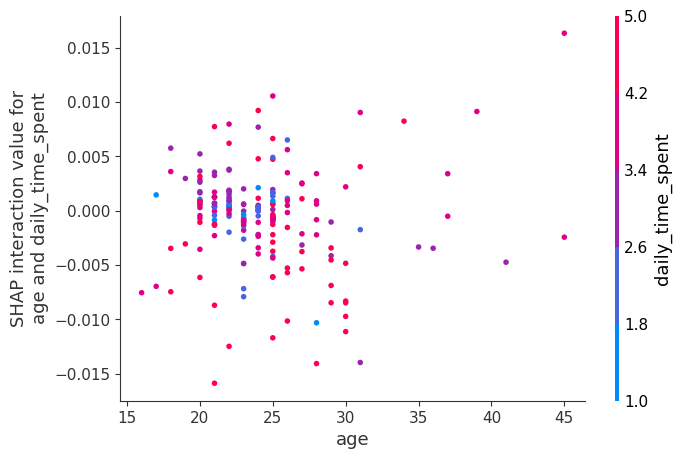


Interaction summary for class 2: Severe Risk
class slice shape: (201, 7, 7)


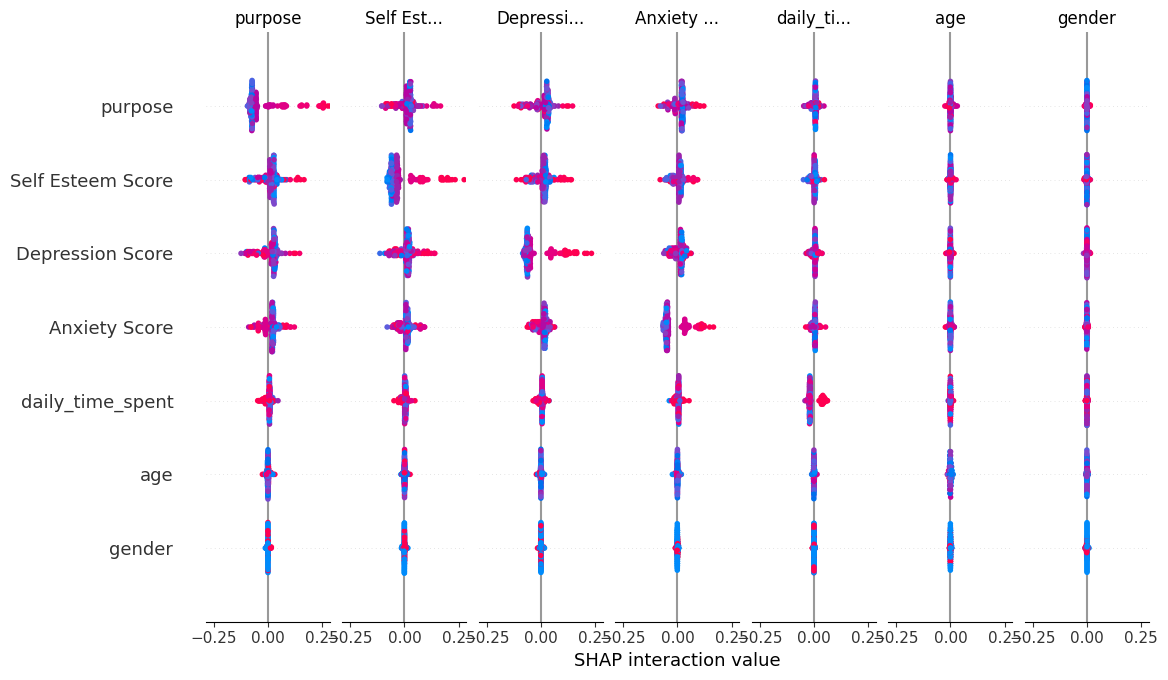

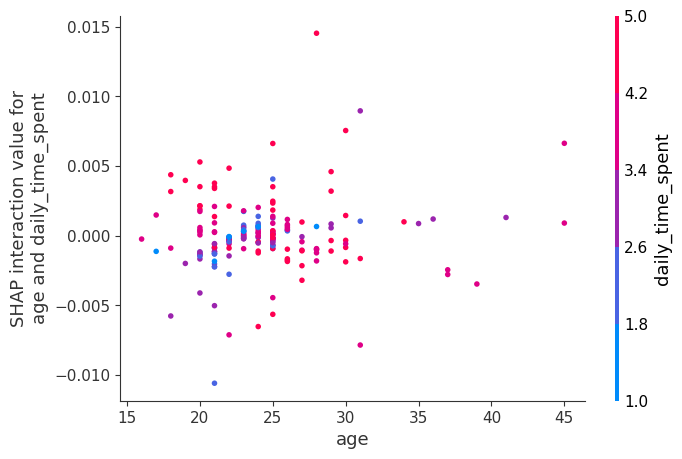

In [ ]:
# ============================================================
# FIXED SHAP INTERACTION PLOT FOR MULTICLASS TREE MODEL
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class_labels = {
    0: "Normal",
    1: "Moderate Risk",
    2: "Severe Risk"
}

feature_names = X_test.columns.tolist()
n_samples, n_features = X_test.shape
n_classes = len(class_labels)

explainer = shap.TreeExplainer(rf_model)
shap_interaction_values = explainer.shap_interaction_values(X_test)

print("type:", type(shap_interaction_values))
print("shape:", np.array(shap_interaction_values).shape if not isinstance(shap_interaction_values, list)
      else [np.array(v).shape for v in shap_interaction_values])

def get_interaction_slice(shap_interaction_values, class_idx, X):
    n_samples, n_features = X.shape
    arr = np.array(shap_interaction_values)

    # Case 1: old SHAP format -> list of (n_samples, n_features, n_features)
    if isinstance(shap_interaction_values, list):
        out = np.array(shap_interaction_values[class_idx])

    # Case 2: single-class or already 3D
    elif arr.ndim == 3:
        out = arr

    # Case 3: multiclass 4D array
    elif arr.ndim == 4:
        # shape: (n_samples, n_features, n_features, n_classes)
        if (
            arr.shape[0] == n_samples and
            arr.shape[1] == n_features and
            arr.shape[2] == n_features
        ):
            out = arr[:, :, :, class_idx]

        # shape: (n_classes, n_samples, n_features, n_features)
        elif (
            arr.shape[1] == n_samples and
            arr.shape[2] == n_features and
            arr.shape[3] == n_features
        ):
            out = arr[class_idx, :, :, :]

        else:
            raise ValueError(f"Unexpected 4D SHAP interaction shape: {arr.shape}")

    else:
        raise ValueError(f"Unsupported SHAP interaction shape: {arr.shape}")

    if out.shape != (n_samples, n_features, n_features):
        raise ValueError(
            f"Wrong interaction slice shape: {out.shape}, "
            f"expected {(n_samples, n_features, n_features)}"
        )

    return out

# ------------------------------------------------------------
# Plot per class
# ------------------------------------------------------------
for class_idx in range(n_classes):
    class_siv = get_interaction_slice(shap_interaction_values, class_idx, X_test)

    print(f"\nInteraction summary for class {class_idx}: {class_labels[class_idx]}")
    print("class slice shape:", class_siv.shape)

    shap.summary_plot(
        class_siv,
        X_test,
        feature_names=feature_names,
        show=True
    )

    # pairwise interaction dependence plot
    shap.dependence_plot(
        ("age", "daily_time_spent"),
        class_siv,
        X_test,
        feature_names=feature_names,
        display_features=X_test,
        show=True
    )

Pearson Correlation Coefficients
                      age  gender  daily_time_spent  purpose  Anxiety Score  \
age                1.0000  0.0014            0.1030   0.0770         0.0765   
gender             0.0014  1.0000            0.0020   0.0425         0.0976   
daily_time_spent   0.1030  0.0020            1.0000   0.4523         0.3203   
purpose            0.0770  0.0425            0.4523   1.0000         0.6153   
Anxiety Score      0.0765  0.0976            0.3203   0.6153         1.0000   
Self Esteem Score  0.0017  0.0326            0.1595   0.3536         0.2346   
Depression Score   0.1127  0.0688            0.1458   0.4951         0.4898   
Outcome            0.0553  0.0531            0.3457   0.6490         0.5026   

                   Self Esteem Score  Depression Score  Outcome  
age                           0.0017            0.1127   0.0553  
gender                        0.0326            0.0688   0.0531  
daily_time_spent              0.1595            0.1458   

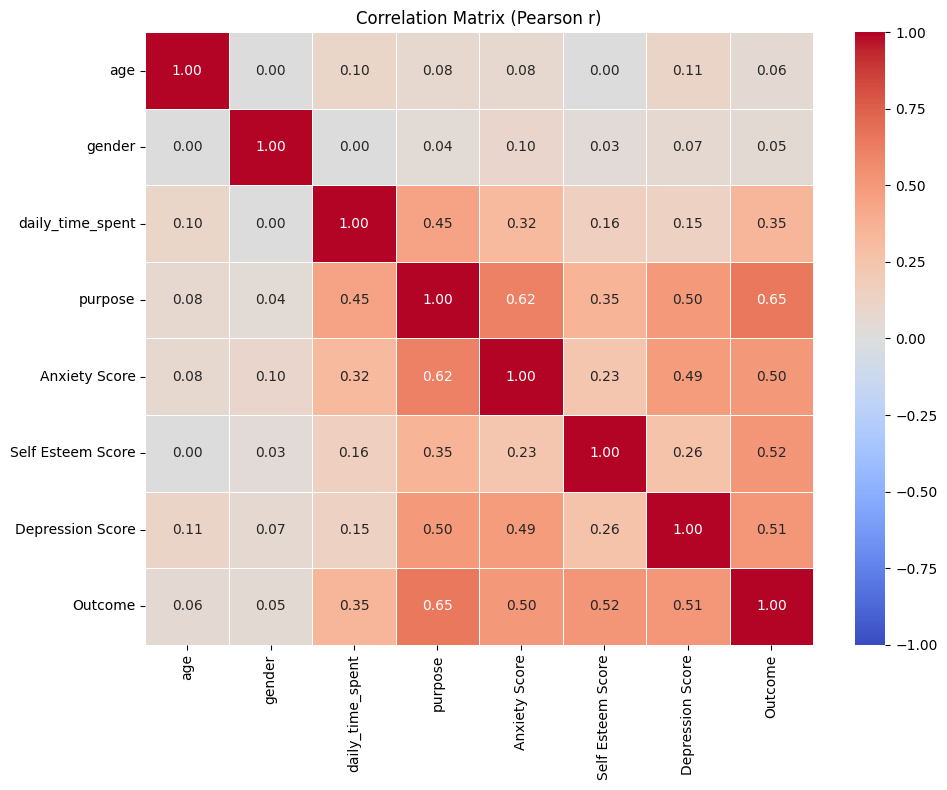

In [ ]:
# ============================================================
# CORRELATION MATRIX WITH P-VALUES
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ------------------------------------------------------------
# Select variables for correlation analysis
# ------------------------------------------------------------
corr_vars = [
    'age',
    'gender',
    'daily_time_spent',
    'purpose',
    'Anxiety Score',
    'Self Esteem Score',
    'Depression Score',
    'Outcome'
]

corr_df = df_model[corr_vars].copy()
corr_df = corr_df.apply(pd.to_numeric, errors='coerce')

# ------------------------------------------------------------
# Function to compute correlation coefficients and p-values
# ------------------------------------------------------------
def corr_with_pvalues(df):
    cols = df.columns
    n = len(cols)

    corr_matrix = pd.DataFrame(np.zeros((n, n)), columns=cols, index=cols)
    p_matrix = pd.DataFrame(np.zeros((n, n)), columns=cols, index=cols)

    for i in range(n):
        for j in range(n):
            x = df[cols[i]]
            y = df[cols[j]]

            valid = pd.concat([x, y], axis=1).dropna()
            if len(valid) > 1:
                r, p = pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])
                corr_matrix.iloc[i, j] = r
                p_matrix.iloc[i, j] = p
            else:
                corr_matrix.iloc[i, j] = np.nan
                p_matrix.iloc[i, j] = np.nan

    return corr_matrix, p_matrix

corr_matrix, p_matrix = corr_with_pvalues(corr_df)

# ------------------------------------------------------------
# Print matrices
# ------------------------------------------------------------
print("Pearson Correlation Coefficients")
print(corr_matrix.round(4))

print("\nP-values for Correlations")
print(p_matrix.round(6))

# ------------------------------------------------------------
# Create a combined table: r with p-value
# ------------------------------------------------------------
combined_table = corr_matrix.copy().astype(str)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        r_val = corr_matrix.iloc[i, j]
        p_val = p_matrix.iloc[i, j]
        combined_table.iloc[i, j] = f"r={r_val:.3f}\np={p_val:.3g}"

print("\nCorrelation Matrix with P-values")
print(combined_table)

# optional save
corr_matrix.to_csv("correlation_coefficients.csv")
p_matrix.to_csv("correlation_pvalues.csv")
combined_table.to_csv("correlation_with_pvalues_combined.csv")

# ------------------------------------------------------------
# Heatmap of correlation coefficients
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Matrix (Pearson r)')
plt.tight_layout()
plt.show()

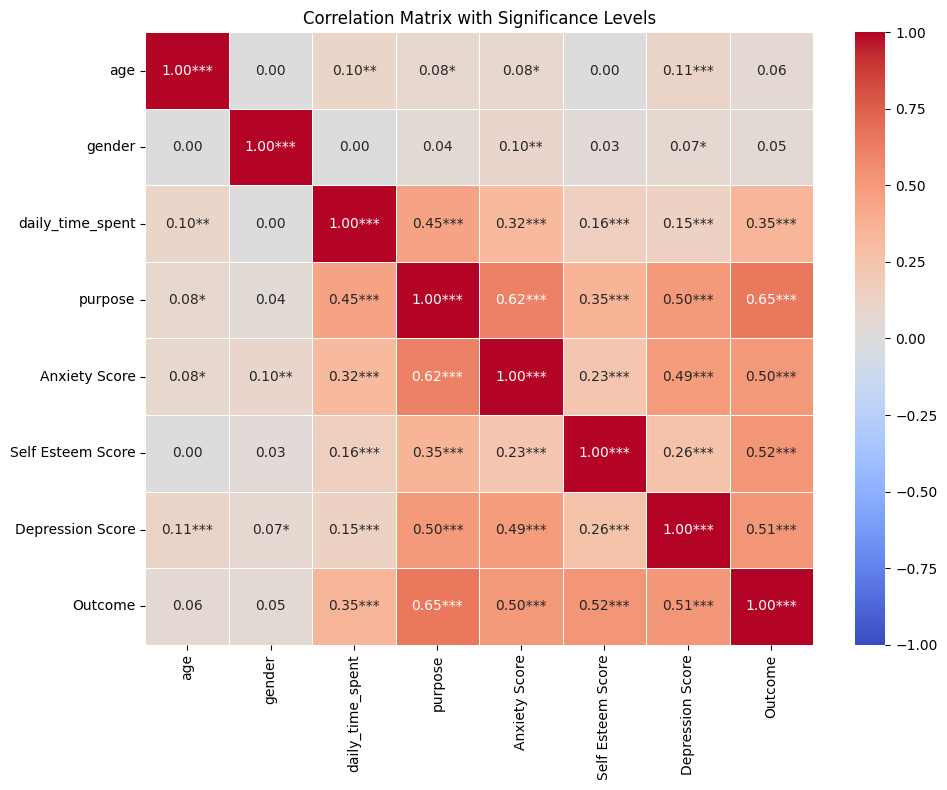

In [ ]:
# ============================================================
# HEATMAP WITH SIGNIFICANCE STARS
# ============================================================

annot_matrix = corr_matrix.copy().astype(str)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        r = corr_matrix.iloc[i, j]
        p = p_matrix.iloc[i, j]

        if pd.isna(r) or pd.isna(p):
            annot_matrix.iloc[i, j] = ""
        else:
            if p < 0.001:
                stars = "***"
            elif p < 0.01:
                stars = "**"
            elif p < 0.05:
                stars = "*"
            else:
                stars = ""
            annot_matrix.iloc[i, j] = f"{r:.2f}{stars}"

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Correlation Matrix with Significance Levels")
plt.tight_layout()
plt.show()